# Tricura — Incident Risk & Severity Modeling

End-to-end modeling notebook. Predicts resident incident risk to help reduce incident
**frequency and severity** at insured facilities. See `README.md` for the full writeup.

## Key findings (read first)

- **Day-30 dynamic model is the workhorse** — ROC-AUC **0.78–0.81** across 20d / 30d / 6m
  horizons, well above the 7–18% positive base rates. Top signals: prior incidents, prior
  hospital transfers, diagnosis burden, vital-sign variability.
- **Thin (day-3 intake) model** reaches ROC-AUC ~0.75 — a 3-day intake window + facility
  baseline risk + fall-risk ICD flags lift it from a near-random pure day-0 model into a usable
  early-triage tool. Top signal: facility baseline risk.
- **Incident-type model** reaches macro-F1 0.44 and catches 48% of Wounds / 40% of Altercations
  (vs an always-Fall baseline that catches none), mapping incidents to the README cost table.
- **Leakage was audited and fixed** (features reconstructed as-of-snapshot); scores held, so the
  signal is genuine.
- **Biggest gap:** the costliest category, return-to-hospital ($20k), lives in `hospital_transfers`
  not `incidents`, so it's out of scope for the type/cost model.

## Notebook structure

| Part | Contents |
|---|---|
| I   | Feature engineering (as-of-snapshot, leakage-safe) |
| II–III | Thin model (day-0): targets, train/CV, evaluation |
| IV  | Dynamic model (day-30): targets, CV, feature selection, evaluation |
| V   | Incident-type & expected-cost model |
| VI  | Export serving artifacts for the API |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

# Part I — Feature Engineering
## 1. Setup & Data Loading

In [2]:
DATA_DIR = Path("data")

USE = [
    "residents", "diagnoses", "physician_orders", "needs",
    "care_plans", "hospital_admissions", "hospital_transfers",
    "medications", "lab_reports", "therapy_tracks", "incidents",
    "vitals",  # dynamic model only
]

dfs = {name: pd.read_parquet(DATA_DIR / f"{name}.parquet") for name in USE}

for name, df in dfs.items():
    print(f"  {name:25s}  {df.shape[0]:>8,} rows × {df.shape[1]} cols")

  residents                     3,000 rows × 9 cols
  diagnoses                    60,620 rows × 8 cols
  physician_orders             94,051 rows × 10 cols
  needs                       162,762 rows × 11 cols
  care_plans                    3,034 rows × 9 cols
  hospital_admissions           2,945 rows × 9 cols
  hospital_transfers            1,816 rows × 12 cols
  medications                1,430,877 rows × 8 cols
  lab_reports                  13,334 rows × 9 cols
  therapy_tracks                  761 rows × 7 cols
  incidents                     3,578 rows × 8 cols
  vitals                     2,517,056 rows × 9 cols


## 2. Population

Load residents and incidents. No filters applied — every admitted resident is scored at admission.  
Target labels are constructed in Part II after feature engineering.

### 2a. Stay Duration Analysis — informs minimum observation window

In [3]:
_residents = dfs["residents"].copy()
_incidents = dfs["incidents"][~dfs["incidents"]["strikeout"]].copy()

ref_date = pd.Timestamp("today").normalize()
_residents["admit"]     = pd.to_datetime(_residents["admission_date"])
_residents["discharge"] = pd.to_datetime(_residents["discharge_date"]).fillna(ref_date)
_residents["los_days"]  = (_residents["discharge"] - _residents["admit"]).dt.days.clip(lower=0)

# apply the same 30-day filter used in modeling
_residents = _residents[_residents["los_days"] >= 30].reset_index(drop=True)

data_end = pd.to_datetime(max(
    dfs["incidents"]["occurred_at"].max(),
    dfs["residents"]["updated_at"].max(),
    dfs["hospital_admissions"]["created_at"].max(),
)).normalize()

print(f"Inferred data end date : {data_end.date()}")
print(f"Residents after 30d filter: {len(_residents):,}")

SNAPSHOT_DAYS = 30
print(f"\n--- Eligible population per forecast window (snapshot = admission + {SNAPSHOT_DAYS}d) ---")
print(f"{'Window':>10}  {'Eligible':>10}  {'Positives':>12}  {'Incident rate':>14}")

for window_days, label in [(180, "6 months"), (365, "12 months")]:
    cutoff   = data_end - pd.Timedelta(days=SNAPSHOT_DAYS + window_days)
    eligible = _residents[_residents["admit"] <= cutoff].copy()
    eligible["snapshot_date"] = eligible["admit"] + pd.Timedelta(days=SNAPSHOT_DAYS)
    eligible["window_end"]    = eligible["snapshot_date"] + pd.Timedelta(days=window_days)

    inc_in_window = set()
    for _, row in eligible.iterrows():
        res_inc = _incidents[
            (_incidents["resident_id"] == row["resident_id"]) &
            (_incidents["occurred_at"] >= row["snapshot_date"]) &
            (_incidents["occurred_at"] <= row["window_end"])
        ]
        if len(res_inc):
            inc_in_window.add(row["resident_id"])

    n     = len(eligible)
    n_pos = len(inc_in_window)
    rate  = 100 * n_pos / n if n > 0 else 0
    print(f"  {label:>10}  {n:>10,}  {n_pos:>12,}  {rate:>13.1f}%")

Inferred data end date : 2026-02-24
Residents after 30d filter: 1,829

--- Eligible population per forecast window (snapshot = admission + 30d) ---
    Window    Eligible     Positives   Incident rate


    6 months       1,829           325           17.8%


   12 months       1,829           398           21.8%


In [4]:
residents = dfs["residents"].copy()
incidents = dfs["incidents"][~dfs["incidents"]["strikeout"]].copy()

# admission_dates used by all feature functions to filter to day-0 knowledge
admission_dates = pd.to_datetime(residents.set_index("resident_id")["admission_date"])

print(f"Residents:  {len(residents):,}")
print(f"Incidents:  {len(incidents):,}  (strikeouts removed)")
print(f"Admission range: {admission_dates.min().date()} → {admission_dates.max().date()}")

Residents:  3,000
Incidents:  3,382  (strikeouts removed)
Admission range: 2005-02-23 → 2024-12-31


## 3. Feature Engineering

One function per source dataset, each returning a resident-level DataFrame indexed on `resident_id`.  
All functions filter records to `<= admission_date` so only information available at day-0 is used.

In [5]:
def _filter_to_admission(df: pd.DataFrame, date_col: str,
                         admission_dates: pd.Series, strict: bool = False) -> pd.DataFrame:
    """Keep rows where date_col <= resident's admission_date (< if strict)."""
    d = df.copy()
    d["_admit"] = pd.to_datetime(d["resident_id"].map(admission_dates))
    rec = pd.to_datetime(d[date_col])
    mask = rec < d["_admit"] if strict else rec <= d["_admit"]
    return d[mask].drop(columns=["_admit"])

### 3.1 Residents — demographics & stay metadata

In [6]:
def feat_residents(df: pd.DataFrame) -> pd.DataFrame:
    r = df[["resident_id", "date_of_birth", "admission_date"]].copy()

    # age at admission — not today, avoids drift when model is reused later
    r["age_at_admission"] = (
        pd.to_datetime(r["admission_date"]) - pd.to_datetime(r["date_of_birth"])
    ).dt.days / 365.25

    # dropped: length_of_stay (0 at day-0), is_deceased/is_discharged (competing events),
    # is_outpatient (1.8% prevalence + contradicts 30-day residency in the dynamic model)
    return r[["resident_id", "age_at_admission"]].set_index("resident_id")

feat_res = feat_residents(residents)
print(feat_res.shape)
feat_res.describe()

(3000, 1)


,age_at_admission
count,2998.0000
mean,74.3594
std,12.5150
min,23.5565
25%,66.1732
50%,75.4168
75%,83.5086
max,104.4298


### 3.2 Diagnoses

In [7]:
def feat_diagnoses(df: pd.DataFrame, snapshot_dates: pd.Series) -> pd.DataFrame:
    d = _filter_to_admission(df[~df["strikeout"]], "created_at", snapshot_dates).copy()

    # active AS OF snapshot: not resolved, or resolved after the snapshot date
    # (resolved_at.isna() alone would leak future resolutions)
    snap = pd.to_datetime(d["resident_id"].map(snapshot_dates))
    resolved = pd.to_datetime(d["resolved_at"])
    d["_active"] = resolved.isna() | (resolved > snap)

    agg = d.groupby("resident_id").agg(
        total_diagnoses=("diagnosis_id", "count"),
        active_diagnoses=("_active", "sum"),
    )
    # has_missing_icd dropped — data-entry artifact, not a clinical signal
    agg["chronic_diagnosis_rate"] = (
        agg["active_diagnoses"] / agg["total_diagnoses"].replace(0, np.nan)
    )

    # exclude chapters irrelevant to a geriatric population: Q (congenital), U (special-purpose)
    IRRELEVANT_CHAPTERS = {"Q", "U"}
    d["icd_chapter"] = d["icd_10_code"].str[:1]
    d = d[~d["icd_chapter"].isin(IRRELEVANT_CHAPTERS)]
    chapter_counts = d.groupby(["resident_id", "icd_chapter"]).size().unstack(fill_value=0)
    chapter_prev   = (chapter_counts > 0).mean()
    keep_chapters  = chapter_prev[chapter_prev >= 0.02].index
    chapter_flags  = (chapter_counts[keep_chapters] > 0).astype(int)
    chapter_flags.columns = [f"icd_chapter_{c}" for c in chapter_flags.columns]

    return agg.join(chapter_flags, how="left").fillna(0)

feat_dx = feat_diagnoses(dfs["diagnoses"], admission_dates)
print(feat_dx.shape)
feat_dx.head(3)

(974, 22)


,total_diagnoses,active_diagnoses,chronic_diagnosis_rate,icd_chapter_A,icd_chapter_B,icd_chapter_C,icd_chapter_D,icd_chapter_E,icd_chapter_F,icd_chapter_G,icd_chapter_H,icd_chapter_I,icd_chapter_J,icd_chapter_K,icd_chapter_L,icd_chapter_M,icd_chapter_N,icd_chapter_R,icd_chapter_S,icd_chapter_T,icd_chapter_W,icd_chapter_Z
resident_id,,,,,,,,,,,,,,,,,,,,,,
0040c381-e248-5ef9-a3cb-027518c91e65,22,22,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000
009693fd-83db-505d-9284-87a6a2397ed2,3,3,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000
00c0fe34-80a2-518f-9d69-dc34e040911b,19,19,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000


### 3.3 Physician Orders

In [8]:
def feat_physician_orders(df: pd.DataFrame, snapshot_dates: pd.Series) -> pd.DataFrame:
    d = _filter_to_admission(
        df.drop(columns=["frequency"], errors="ignore"), "ordered_at", snapshot_dates
    ).copy()

    # active AS OF snapshot, reconstructed from dates — order_status reflects *now*, which leaks
    snap = pd.to_datetime(d["resident_id"].map(snapshot_dates))
    end  = pd.to_datetime(d["end_at"])
    d["_active"] = end.isna() | (end > snap)

    agg = d.groupby("resident_id").agg(
        total_orders=("order_id", "count"),
        active_orders=("_active", "sum"),
        open_ended_orders=("end_at", lambda x: x.isna().sum()),
    )
    agg["open_ended_order_rate"] = (
        agg["open_ended_orders"] / agg["total_orders"].replace(0, np.nan)
    )

    cat_counts = d.groupby(["resident_id", "category"]).size().unstack(fill_value=0)
    cat_prev   = (cat_counts > 0).mean()
    keep_cats  = cat_prev[cat_prev >= 0.05].index
    cat_flags  = (cat_counts[keep_cats] > 0).astype(int)
    cat_flags.columns = [f"order_cat_{c.lower().replace(' ', '_')}" for c in cat_flags.columns]

    return agg.join(cat_flags, how="left").fillna(0)

feat_orders = feat_physician_orders(dfs["physician_orders"], admission_dates)
print(feat_orders.shape)
feat_orders.head(3)

(599, 10)


,total_orders,active_orders,open_ended_orders,open_ended_order_rate,order_cat_diagnostic,order_cat_dietary_-_diet,order_cat_dietary_-_supplements,order_cat_laboratory,order_cat_other,order_cat_pharmacy
resident_id,,,,,,,,,,
016b424f-556e-5bc3-8190-6c472be7f8bb,71,67,67,0.9437,0,1,0,0,1,1
029b174a-6ae4-5220-b7d0-ab68b8f9d521,22,22,19,0.8636,0,1,0,0,1,0
02b95836-2f30-5a66-a3c2-d8c850942ea5,31,22,21,0.6774,1,1,1,1,1,1


### 3.4 Needs

In [9]:
def feat_needs(df: pd.DataFrame, snapshot_dates: pd.Series) -> pd.DataFrame:
    # the current_row flag marks the latest version *now* — leaky. Instead, take the
    # latest version of each need as of the snapshot date.
    d = _filter_to_admission(df[~df["strikeout"]], "initiated_at", snapshot_dates).copy()
    d = d.sort_values("initiated_at").drop_duplicates("need_id", keep="last")

    snap = pd.to_datetime(d["resident_id"].map(snapshot_dates))
    resolved = pd.to_datetime(d["resolved_at"])
    d["_unresolved"] = resolved.isna() | (resolved > snap)

    agg = d.groupby("resident_id").agg(
        total_needs=("need_id", "count"),
        unresolved_needs=("_unresolved", "sum"),
    )
    agg["unresolved_needs_rate"] = (
        agg["unresolved_needs"] / agg["total_needs"].replace(0, np.nan)
    )
    cat_counts = d.groupby(["resident_id", "need_category"]).size().unstack(fill_value=0)
    cat_prev   = (cat_counts > 0).mean()
    keep_cats  = cat_prev[cat_prev >= 0.05].index
    cat_flags  = (cat_counts[keep_cats] > 0).astype(int)
    cat_flags.columns = [f"need_cat_{c.lower().replace(' ', '_')}" for c in cat_flags.columns]
    return agg.join(cat_flags, how="left").fillna(0)

feats_needs = feat_needs(dfs["needs"], admission_dates)
print(feats_needs.shape)
feats_needs.head(3)

(1001, 7)


,total_needs,unresolved_needs,unresolved_needs_rate,need_cat_fall,need_cat_nutrition,need_cat_other,need_cat_wound
resident_id,,,,,,,
000d4288-4983-5512-b4e8-bf5efa8e20ef,23,23,1.0000,1,0,1,1
0040c381-e248-5ef9-a3cb-027518c91e65,7,7,1.0000,0,1,1,0
00923d0e-adba-5def-b51b-0afd3a5831bd,9,9,1.0000,0,0,1,0


### 3.5 Care Plans

In [10]:
def feat_care_plans(df: pd.DataFrame, residents_df: pd.DataFrame,
                    snapshot_dates: pd.Series) -> pd.DataFrame:
    d = _filter_to_admission(df[~df["strikeout"]], "initiated_at", snapshot_dates).copy()

    # open AS OF snapshot: not closed, or closed after the snapshot date
    snap = pd.to_datetime(d["resident_id"].map(snapshot_dates))
    closed = pd.to_datetime(d["closed_at"])
    d["_open"] = closed.isna() | (closed > snap)

    agg = d.groupby("resident_id").agg(
        total_care_plans=("care_plan_id", "count"),
        open_care_plans=("_open", "sum"),
    )
    agg["care_plan_open_rate"] = (
        agg["open_care_plans"] / agg["total_care_plans"].replace(0, np.nan)
    )

    # overdue AS OF snapshot: plan open at snapshot AND its review was already due then
    open_plans = d[d["_open"]].copy()
    open_plans["_snap"] = pd.to_datetime(open_plans["resident_id"].map(snapshot_dates))
    open_plans["overdue"] = pd.to_datetime(open_plans["next_review_at"]) < open_plans["_snap"]
    overdue = (
        open_plans.groupby("resident_id")["overdue"].any()
        .astype(int).rename("has_overdue_review")
    )
    return agg.join(overdue, how="left").fillna(0)

feat_cp = feat_care_plans(dfs["care_plans"], residents, admission_dates)
print(feat_cp.shape)
feat_cp.head(3)

(851, 4)


,total_care_plans,open_care_plans,care_plan_open_rate,has_overdue_review
resident_id,,,,
000d4288-4983-5512-b4e8-bf5efa8e20ef,1,1,1.0000,0.0000
00923d0e-adba-5def-b51b-0afd3a5831bd,1,1,1.0000,0.0000
009a1d0c-82a7-508d-96bc-ff91ab79e3e7,1,1,1.0000,0.0000


### 3.6 Hospital Admissions & Transfers

In [11]:
def feat_hospital(admissions: pd.DataFrame, transfers: pd.DataFrame,
                  snapshot_dates: pd.Series) -> pd.DataFrame:
    # strict=True: prior admissions only (exclude current one)
    adm = _filter_to_admission(
        admissions.drop(columns=["emergency_flag"], errors="ignore"),
        "effective_date", snapshot_dates, strict=True
    )
    adm_agg = adm.groupby("resident_id").agg(
        prior_admission_count=("admission_id", "count"),
    )
    # is_readmission doubles as the "has prior admission" flag — it disambiguates
    # days_since_last_discharge (=-1 means no prior admission, not "0 days ago")
    adm_agg["is_readmission"] = (adm_agg["prior_admission_count"] > 0).astype(int)

    last_discharge = adm.groupby("resident_id")["ineffective_date"].max().pipe(pd.to_datetime)
    days_since = (snapshot_dates - last_discharge).dt.days
    days_since.name = "days_since_last_discharge"
    adm_agg = adm_agg.join(days_since, how="left")
    adm_agg["days_since_last_discharge"] = adm_agg["days_since_last_discharge"].fillna(-1)

    tr = _filter_to_admission(transfers.copy(), "effective_date", snapshot_dates, strict=True)
    tr["emergency_flag"] = tr["emergency_flag"].map(
        lambda x: 1 if str(x).strip().lower() in ("true", "1", "yes") else 0
    )
    tr["planned_flag"] = tr["planned_flag"].map(
        lambda x: 0 if str(x).strip().lower() in ("true", "1", "yes") else 1
    )
    tr_agg = tr.groupby("resident_id").agg(
        prior_transfer_count=("transfer_id", "count"),
        emergency_transfer_count=("emergency_flag", "sum"),
        unplanned_transfer_count=("planned_flag", "sum"),
    )
    outcome_counts = tr.groupby(["resident_id", "transfer_outcome"]).size().unstack(fill_value=0)
    outcome_prev   = (outcome_counts > 0).mean()
    keep = outcome_prev[outcome_prev >= 0.05].index
    if len(keep):
        outcome_flags = (outcome_counts[keep] > 0).astype(int)
        outcome_flags.columns = [
            f"transfer_outcome_{c.lower().replace(' ', '_')}" for c in outcome_flags.columns
        ]
        tr_agg = tr_agg.join(outcome_flags, how="left").fillna(0)

    result = adm_agg.join(tr_agg, how="outer")
    # residents seen only via transfers have no admission-derived days_since
    result["days_since_last_discharge"] = result["days_since_last_discharge"].fillna(-1)
    return result.fillna(0)

feat_hosp = feat_hospital(dfs["hospital_admissions"], dfs["hospital_transfers"], admission_dates)
print(feat_hosp.shape)
feat_hosp.head(3)

(476, 11)


,prior_admission_count,is_readmission,days_since_last_discharge,prior_transfer_count,emergency_transfer_count,unplanned_transfer_count,"transfer_outcome_admitted,_inpatient","transfer_outcome_admitted,_observation","transfer_outcome_admitted,_status_uncertain",transfer_outcome_ed_visit_only,transfer_outcome_other
resident_id,,,,,,,,,,,
0121c842-fecc-598d-980b-53d29669613a,3.0000,1.0000,15.0000,4.0000,0.0000,4.0000,1.0000,0.0000,0.0000,1.0000,0.0000
016b424f-556e-5bc3-8190-6c472be7f8bb,4.0000,1.0000,4.0000,5.0000,0.0000,2.0000,1.0000,0.0000,0.0000,0.0000,1.0000
02b95836-2f30-5a66-a3c2-d8c850942ea5,0.0000,0.0000,-1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### 3.7 Medications

In [12]:
def feat_medications(df: pd.DataFrame, snapshot_dates: pd.Series) -> pd.DataFrame:
    d = _filter_to_admission(df, "scheduled_at", snapshot_dates).copy()

    # missed AS OF snapshot: not administered, or administered after the snapshot date
    snap = pd.to_datetime(d["resident_id"].map(snapshot_dates))
    admin = pd.to_datetime(d["administered_at"])
    d["_missed"] = admin.isna() | (admin > snap)

    agg = d.groupby("resident_id").agg(
        scheduled_dose_count=("medication_id", "count"),
        missed_dose_count=("_missed", "sum"),
        unique_medications=("description", "nunique"),
    )
    agg["missed_dose_rate"] = (
        agg["missed_dose_count"] / agg["scheduled_dose_count"].replace(0, np.nan)
    )
    agg["medication_adherence"] = np.where(agg["missed_dose_count"] == 0, 1, 2)
    return agg

feat_meds = feat_medications(dfs["medications"], admission_dates)
print(feat_meds.shape)
feat_meds.describe()

(111, 5)


,scheduled_dose_count,missed_dose_count,unique_medications,missed_dose_rate,medication_adherence
count,111.0000,111.0000,111.0000,111.0000,111.0000
mean,3223.6306,256.2523,44.8378,0.3351,1.9369
std,5324.6561,507.4244,50.7841,0.4168,0.2442
min,1.0000,0.0000,1.0000,0.0000,1.0000
25%,10.0000,3.5000,10.0000,0.0354,2.0000
50%,572.0000,29.0000,32.0000,0.0935,2.0000
75%,4535.0000,224.0000,56.0000,1.0000,2.0000
max,28878.0000,2380.0000,288.0000,1.0000,2.0000


### 3.8 Lab Reports

In [13]:
def feat_labs(df: pd.DataFrame, snapshot_dates: pd.Series) -> pd.DataFrame:
    d = _filter_to_admission(df, "reported_at", snapshot_dates)
    d["is_abnormal"] = ~d["severity_status"].str.lower().str.strip().isin(["normal", ""])
    agg = d.groupby("resident_id").agg(
        lab_count=("lab_report_id", "count"),
        abnormal_lab_count=("is_abnormal", "sum"),
        unique_lab_types=("lab_name", "nunique"),
    )
    agg["abnormal_lab_rate"] = (
        agg["abnormal_lab_count"] / agg["lab_count"].replace(0, np.nan)
    )
    agg["lab_abnormality"] = np.where(agg["abnormal_lab_count"] == 0, 1, 2)
    return agg

feats_labs = feat_labs(dfs["lab_reports"], admission_dates)
print(feats_labs.shape)
feats_labs.describe()

(272, 5)


,lab_count,abnormal_lab_count,unique_lab_types,abnormal_lab_rate,lab_abnormality
count,272.0000,272.0000,272.0000,272.0000,272.0000
mean,13.5772,11.0625,7.6581,0.8330,1.9890
std,19.6135,16.6623,7.9827,0.2090,0.1046
min,1.0000,0.0000,1.0000,0.0000,1.0000
25%,4.0000,3.0000,3.0000,0.7452,2.0000
50%,8.0000,6.0000,5.0000,0.9091,2.0000
75%,17.0000,13.0000,9.0000,1.0000,2.0000
max,246.0000,213.0000,73.0000,1.0000,2.0000


### 3.9 Therapy Tracks

### 3.10 Prior Incidents

Incidents that occurred before the current admission — strong signal for readmitted residents.

In [14]:
def feat_prior_incidents(incidents_df: pd.DataFrame, admission_dates: pd.Series) -> pd.DataFrame:
    # strict=True: only incidents before current admission
    d = _filter_to_admission(incidents_df, "occurred_at", admission_dates, strict=True)
    agg = d.groupby("resident_id").agg(
        prior_incident_count=("incident_id", "count"),
    )
    return agg

feat_prior_inc = feat_prior_incidents(incidents, admission_dates)
print(feat_prior_inc.shape)
print(f"Residents with prior incidents: {len(feat_prior_inc):,}")
feat_prior_inc["prior_incident_count"].describe()

(210, 1)
Residents with prior incidents: 210


count   210.0000
mean      3.2714
std       3.6743
min       1.0000
25%       1.0000
50%       2.0000
75%       4.0000
max      27.0000
Name: prior_incident_count, dtype: float64

### 3.11 Vitals — Dynamic Model Only

Aggregated within the snapshot window (admission → snapshot date).  
Outliers capped per vital type at 1st–99th percentile. Only types with >10% resident coverage kept.

In [15]:
def feat_vitals(df: pd.DataFrame, snapshot_dates: pd.Series,
                start_dates: pd.Series = None) -> pd.DataFrame:
    d = _filter_to_admission(df[~df["strikeout"]], "measured_at", snapshot_dates)

    if start_dates is not None:
        d = d.copy()
        d["_start"] = pd.to_datetime(d["resident_id"].map(start_dates))
        d = d[pd.to_datetime(d["measured_at"]) >= d["_start"]].drop(columns=["_start"])

    if d.empty:
        return pd.DataFrame()

    # cap outliers per vital_type using transform (preserves all columns)
    def clip_group(s):
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        return s.clip(lo, hi)

    d = d.copy()
    d["value_capped"] = d.groupby("vital_type")["value"].transform(clip_group)

    # keep only vital types present in >10% of residents
    n_total = snapshot_dates.shape[0]
    coverage = d.groupby("vital_type")["resident_id"].nunique()
    prevalent = coverage[coverage / n_total >= 0.10].index
    d = d[d["vital_type"].isin(prevalent)]

    if d.empty:
        return pd.DataFrame()

    # mean, std, count per resident per vital_type → flatten columns
    agg = (
        d.groupby(["resident_id", "vital_type"])["value_capped"]
        .agg(["mean", "std", "count"])
        .unstack("vital_type")
    )
    agg.columns = [
        f"vital_{stat}_{vt.lower().replace(' ', '_').replace('/', '_').replace('(','').replace(')','')}"
        for stat, vt in agg.columns
    ]
    return agg.fillna(0)

print("feat_vitals defined — called during dynamic model assembly")

feat_vitals defined — called during dynamic model assembly


In [16]:
def feat_therapy(df: pd.DataFrame, snapshot_dates: pd.Series) -> pd.DataFrame:
    d = _filter_to_admission(df, "start_at", snapshot_dates)
    agg = d.groupby("resident_id").agg(
        has_therapy=("therapy_id", lambda x: int(len(x) > 0)),
        therapy_discipline_count=("discipline", "nunique"),
    )
    return agg

feats_therapy = feat_therapy(dfs["therapy_tracks"], admission_dates)
print(feats_therapy.shape)
feats_therapy.head(3)

(64, 2)


,has_therapy,therapy_discipline_count
resident_id,,
02f8f51e-6c29-5c70-bfb0-e1b9abb05433,1,1
04fcbc3d-5976-5bf8-bdb4-adfbc936b43a,1,2
072691ff-60ba-5d4c-a8b4-ba582a99d803,1,1


## 4. Feature Assembly — Thin Model (Day-0 Snapshot)

In [17]:
# Thin model uses a 3-DAY INTAKE WINDOW (admission + 3d), not pure day-0: it captures the
# admission workup (diagnoses, orders, meds), the richest early signal. Pure day-0 is near-random
# (ROC-AUC ~0.52); intake + facility risk + ICD flags lifts it to ~0.75 — see experiment at the end.
INTAKE_DAYS = 3
intake_dates = admission_dates + pd.Timedelta(days=INTAKE_DAYS)

base = residents[["resident_id", "admission_date"]].set_index("resident_id")

intake_blocks = [
    feat_residents(residents),
    feat_diagnoses(dfs["diagnoses"], intake_dates),
    feat_physician_orders(dfs["physician_orders"], intake_dates),
    feat_needs(dfs["needs"], intake_dates),
    feat_care_plans(dfs["care_plans"], residents, intake_dates),
    feat_hospital(dfs["hospital_admissions"], dfs["hospital_transfers"], intake_dates),
    feat_medications(dfs["medications"], intake_dates),
    feat_labs(dfs["lab_reports"], intake_dates),
    feat_therapy(dfs["therapy_tracks"], intake_dates),
    feat_prior_incidents(incidents, intake_dates),
]

# specific fall-risk ICD flags present at intake
_dxi = _filter_to_admission(dfs["diagnoses"][~dfs["diagnoses"]["strikeout"]],
                            "created_at", intake_dates).copy()
_code = _dxi["icd_10_code"].fillna("").str.replace(".", "", regex=False).str.upper()
_dxi["fall_hist"] = _code.str.startswith("Z9181")
_dxi["dementia"]  = _code.str.startswith(("F00", "F01", "F02", "F03", "G30"))
_dxi["gait"]      = _code.str.startswith("R26")
_dxi["parkinson"] = _code.str.startswith("G20")
icd_flags = _dxi.groupby("resident_id")[["fall_hist", "dementia", "gait", "parkinson"]].any().astype(int)
icd_flags.columns = ["dx_" + c for c in icd_flags.columns]

X_all = base.join(intake_blocks + [icd_flags], how="left")
for col in ("medication_adherence", "lab_abnormality"):
    X_all[col] = X_all[col].fillna(0).astype(int)
X_all["days_since_last_discharge"] = X_all["days_since_last_discharge"].fillna(-1)
X_all = X_all.fillna(0)

# facility_risk is target-encoded per window, so it is added per window in the training cell
feature_cols = [c for c in X_all.columns if c != "admission_date"]
print(f"Thin (day-3 intake) feature matrix: {X_all.shape[0]:,} x {len(feature_cols)} features")

Thin (day-3 intake) feature matrix: 3,000 x 72 features


# Part II — Thin Model (Day-0 Score)

Predicts 6-month and 12-month incident risk at admission using only pre-admission information.  
Intended as an immediate triage score — updated at day 30 by the dynamic model.

In [18]:
DATA_END = pd.Timestamp("2026-02-24")  # inferred from data analysis

discharge_dates = pd.to_datetime(
    residents.set_index("resident_id")["discharge_date"]
)

def build_target(incidents_df, admission_dates, discharge_dates, window_days, data_end):
    window_end = (admission_dates + pd.Timedelta(days=window_days)).clip(upper=data_end)
    # further bound by discharge if resident left before window closes
    bounded_end = pd.concat([window_end, discharge_dates], axis=1).min(axis=1, skipna=True)
    bounded_end.name = "window_end"

    inc = incidents_df[["resident_id", "occurred_at"]].copy()
    inc["window_start"] = inc["resident_id"].map(admission_dates)
    inc["window_end"]   = inc["resident_id"].map(bounded_end)

    in_window = inc[
        (pd.to_datetime(inc["occurred_at"]) >= pd.to_datetime(inc["window_start"])) &
        (pd.to_datetime(inc["occurred_at"]) <= pd.to_datetime(inc["window_end"]))
    ]
    positives = set(in_window["resident_id"].unique())
    return pd.Series(
        admission_dates.index.isin(positives).astype(int),
        index=admission_dates.index,
    )

y_6m  = build_target(incidents, admission_dates, discharge_dates, 180, DATA_END)
y_12m = build_target(incidents, admission_dates, discharge_dates, 365, DATA_END)

print(f"6-month target  — positives: {y_6m.sum():,} / {len(y_6m):,} ({100*y_6m.mean():.1f}%)")
print(f"12-month target — positives: {y_12m.sum():,} / {len(y_12m):,} ({100*y_12m.mean():.1f}%)")

6-month target  — positives: 566 / 3,000 (18.9%)
12-month target — positives: 648 / 3,000 (21.6%)


# Part III — Thin Model Modeling
## 7. Train / Test Split

In [19]:
sorted_idx   = X_all["admission_date"].sort_values().index
cutoff_idx   = int(len(sorted_idx) * 0.8)
cutoff_date  = X_all.loc[sorted_idx[cutoff_idx], "admission_date"]

train_idx = X_all[X_all["admission_date"] <= cutoff_date].index
test_idx  = X_all[X_all["admission_date"] >  cutoff_date].index

X_train = X_all.loc[train_idx, feature_cols]
X_test  = X_all.loc[test_idx,  feature_cols]

targets = {"6m": y_6m, "12m": y_12m}
y_train = {k: v.loc[train_idx] for k, v in targets.items()}
y_test  = {k: v.loc[test_idx]  for k, v in targets.items()}

print(f"Cutoff: {pd.to_datetime(cutoff_date).date()}")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
for k in targets:
    print(f"  y_{k}  train pos: {y_train[k].sum():,} ({100*y_train[k].mean():.1f}%)  "
          f"test pos: {y_test[k].sum():,} ({100*y_test[k].mean():.1f}%)")

Cutoff: 2024-10-02
Train: 2,401  |  Test: 599
  y_6m  train pos: 462 (19.2%)  test pos: 104 (17.4%)
  y_12m  train pos: 544 (22.7%)  test pos: 104 (17.4%)


## 8. Cross-Validation & Model Training

Time-series cross-validation on the training set using `TimeSeriesSplit` (5 folds).  
CV is run first for model selection; the winning model is then retrained on the full training set and evaluated on the held-out test set.

In [20]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

def make_models(pos_weight: float = 1.0):
    """
    # Gradient boosting methods only — well suited for imbalanced data.
    # pos_weight = neg_count / pos_count — passed to XGBoost.
    HistGBM, RF and LR use class_weight='balanced' from sklearn instead.
    CatBoost uses auto_class_weights='Balanced'.
    """
    return {
    # LogisticRegression removed — linear models have poor recall on minority class
        # and don't benefit from the non-linear decision boundaries that matter here.
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf",     RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                               random_state=42, n_jobs=-1)),
        ]),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            class_weight="balanced", random_state=42, max_iter=300,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            scale_pos_weight=pos_weight,
            random_state=42,
            n_jobs=-1,
            eval_metric="aucpr",
            verbosity=0,
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300,
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=0,
        ),
    }

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {}

# primary metric: average_precision (PR-AUC) — better than ROC-AUC when recall matters
SCORING = "average_precision"

for window in ("6m", "12m"):
    cv_results[window] = {}
    pos_weight = (y_train[window] == 0).sum() / max((y_train[window] == 1).sum(), 1)

    print(f"\n=== Cross-validation: {window} window  (scoring={SCORING}, pos_weight={pos_weight:.1f}) ===")
    print(f"  {'Model':30s}  {'Mean PR-AUC':>12}  {'Std':>8}  Fold scores")

    for name, model in make_models(pos_weight).items():
        scores = cross_val_score(
            model, X_train, y_train[window],
            cv=tscv, scoring=SCORING, n_jobs=-1
        )
        cv_results[window][name] = scores
        print(f"  {name:30s}  {scores.mean():.4f}        ±{scores.std():.4f}  "
              f"{[round(s, 3) for s in scores]}")

best_cv = {
    window: max(cv_results[window], key=lambda k: cv_results[window][k].mean())
    for window in ("6m", "12m")
}
print(f"\nBest model by CV PR-AUC:")
for window, name in best_cv.items():
    mean = cv_results[window][name].mean()
    std  = cv_results[window][name].std()
    print(f"  {window}: {name}  (PR-AUC {mean:.4f} ± {std:.4f})")


=== Cross-validation: 6m window  (scoring=average_precision, pos_weight=4.2) ===
  Model                            Mean PR-AUC       Std  Fold scores


  RandomForest                    0.4324        ±0.0440  [np.float64(0.351), np.float64(0.444), np.float64(0.482), np.float64(0.454), np.float64(0.431)]


  HistGradientBoosting            0.4210        ±0.0374  [np.float64(0.349), np.float64(0.459), np.float64(0.429), np.float64(0.437), np.float64(0.431)]


  XGBoost                         0.4350        ±0.0523  [np.float64(0.385), np.float64(0.516), np.float64(0.452), np.float64(0.45), np.float64(0.371)]


  CatBoost                        0.4851        ±0.0563  [np.float64(0.384), np.float64(0.533), np.float64(0.528), np.float64(0.517), np.float64(0.464)]

=== Cross-validation: 12m window  (scoring=average_precision, pos_weight=3.4) ===
  Model                            Mean PR-AUC       Std  Fold scores


  RandomForest                    0.4058        ±0.0457  [np.float64(0.325), np.float64(0.452), np.float64(0.434), np.float64(0.431), np.float64(0.386)]


  HistGradientBoosting            0.4053        ±0.0598  [np.float64(0.3), np.float64(0.477), np.float64(0.434), np.float64(0.427), np.float64(0.388)]


  XGBoost                         0.4017        ±0.0657  [np.float64(0.316), np.float64(0.484), np.float64(0.419), np.float64(0.454), np.float64(0.336)]


  CatBoost                        0.4646        ±0.0688  [np.float64(0.339), np.float64(0.501), np.float64(0.525), np.float64(0.514), np.float64(0.444)]

Best model by CV PR-AUC:
  6m: CatBoost  (PR-AUC 0.4851 ± 0.0563)
  12m: CatBoost  (PR-AUC 0.4646 ± 0.0688)


In [21]:
from sklearn.model_selection import KFold

# facility baseline risk — out-of-fold smoothed target encoding on train (leakage-safe), per window
_fac = residents.set_index("resident_id")["facility_id"]

def _facility_risk(y_window, smoothing=10.0):
    glob = float(y_window.loc[train_idx].mean())
    fac_tr = _fac.reindex(train_idx)
    oof = pd.Series(index=train_idx, dtype=float)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for fit_pos, val_pos in kf.split(train_idx):
        fit_idx, val_idx = train_idx[fit_pos], train_idx[val_pos]
        g = (pd.DataFrame({"fac": fac_tr.loc[fit_idx], "y": y_window.loc[fit_idx]})
             .groupby("fac")["y"].agg(["sum", "count"]))
        rate = (g["sum"] + smoothing * glob) / (g["count"] + smoothing)
        oof.loc[val_idx] = fac_tr.loc[val_idx].map(rate).fillna(glob)
    g = (pd.DataFrame({"fac": fac_tr, "y": y_window.loc[train_idx]})
         .groupby("fac")["y"].agg(["sum", "count"]))
    full_rate = (g["sum"] + smoothing * glob) / (g["count"] + smoothing)
    test_vals = _fac.reindex(test_idx).map(full_rate).fillna(glob)
    return oof, test_vals, {str(k): float(v) for k, v in full_rate.items()}, glob

results = {}
facility_maps = {}
X_thin_test = {}
thin_features = feature_cols + ["facility_risk"]

for window in ("6m", "12m"):
    oof_tr, te_vals, fac_map, glob = _facility_risk(y_train[window])
    Xtr = X_train.copy(); Xtr["facility_risk"] = oof_tr
    Xte = X_test.copy();  Xte["facility_risk"] = te_vals
    X_thin_test[window] = Xte
    facility_maps[window] = {"rates": fac_map, "global": glob}

    model = CatBoostClassifier(iterations=300, auto_class_weights="Balanced",
                               random_seed=42, verbose=0)
    model.fit(Xtr, y_train[window])
    proba = model.predict_proba(Xte)[:, 1]
    results[window] = {
        "model": model, "name": "CatBoost", "proba": proba, "features": thin_features,
        "roc_auc": roc_auc_score(y_test[window], proba),
        "avg_precision": average_precision_score(y_test[window], proba),
    }
    print(f"[{window}] thin (day-3 intake + facility + ICD)  "
          f"Test PR-AUC={results[window]['avg_precision']:.4f}  "
          f"Test ROC-AUC={results[window]['roc_auc']:.4f}")

[6m] thin (day-3 intake + facility + ICD)  Test PR-AUC=0.4311  Test ROC-AUC=0.7363


[12m] thin (day-3 intake + facility + ICD)  Test PR-AUC=0.4418  Test ROC-AUC=0.7525


## 9. Evaluation

Primary metric: **PR-AUC (Average Precision)** — rewards recall and is robust to class imbalance.  
ROC-AUC shown as secondary reference.

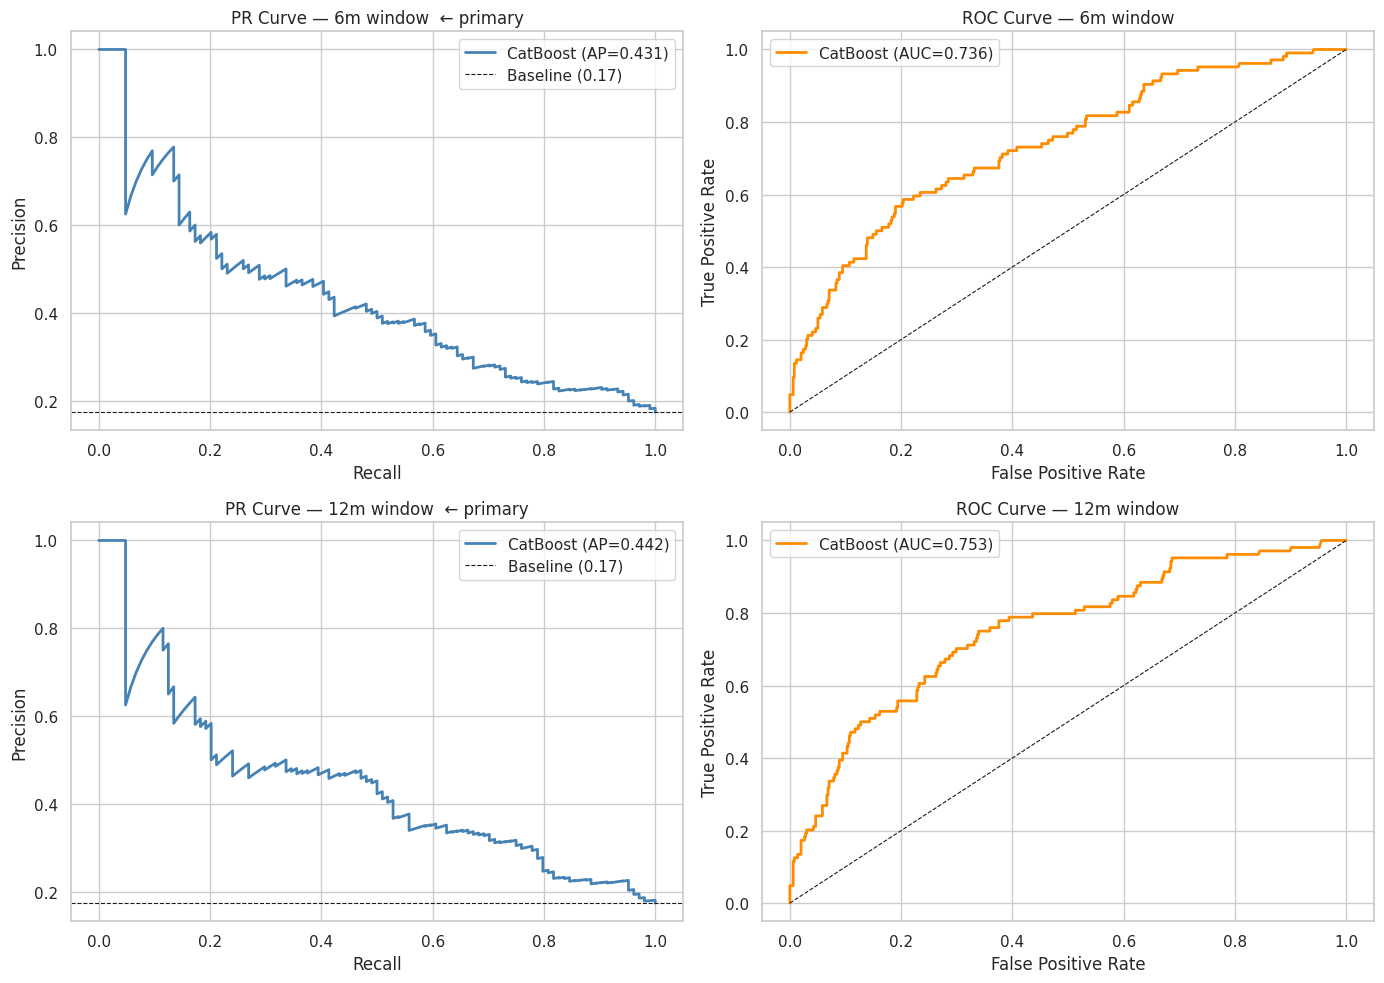

In [22]:
# PR curve (primary) + ROC curve (secondary) side by side per window
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, window in enumerate(("6m", "12m")):
    res   = results[window]
    proba = res["proba"]

    # PR curve — primary
    prec, rec, _ = precision_recall_curve(y_test[window], proba)
    baseline = y_test[window].mean()
    axes[row, 0].plot(rec, prec, color="steelblue", lw=2,
                      label=f"{res['name']} (AP={res['avg_precision']:.3f})")
    axes[row, 0].axhline(baseline, color="k", linestyle="--", lw=0.8,
                         label=f"Baseline ({baseline:.2f})")
    axes[row, 0].set_xlabel("Recall")
    axes[row, 0].set_ylabel("Precision")
    axes[row, 0].set_title(f"PR Curve — {window} window  ← primary")
    axes[row, 0].legend()

    # ROC curve — secondary
    fpr, tpr, _ = roc_curve(y_test[window], proba)
    axes[row, 1].plot(fpr, tpr, color="darkorange", lw=2,
                      label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
    axes[row, 1].plot([0, 1], [0, 1], "k--", lw=0.8)
    axes[row, 1].set_xlabel("False Positive Rate")
    axes[row, 1].set_ylabel("True Positive Rate")
    axes[row, 1].set_title(f"ROC Curve — {window} window")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()


=======================================================  6m window  =======================================================
Best model: CatBoost

              precision    recall  f1-score   support

 No Incident       0.90      0.76      0.82       495
Had Incident       0.34      0.61      0.44       104

    accuracy                           0.73       599
   macro avg       0.62      0.68      0.63       599
weighted avg       0.80      0.73      0.76       599



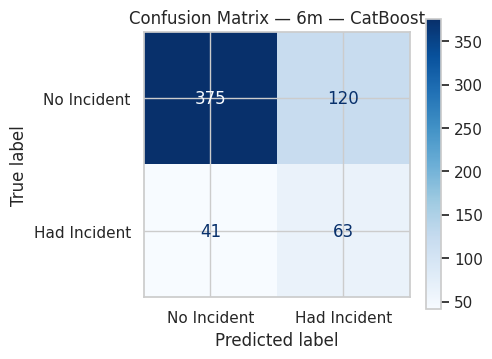


=======================================================  12m window  =======================================================
Best model: CatBoost

              precision    recall  f1-score   support

 No Incident       0.90      0.77      0.83       495
Had Incident       0.35      0.59      0.44       104

    accuracy                           0.74       599
   macro avg       0.62      0.68      0.63       599
weighted avg       0.80      0.74      0.76       599



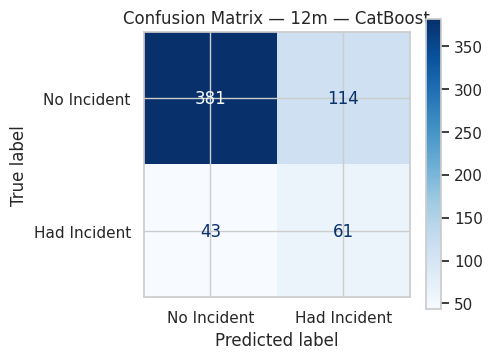

In [23]:
for window in ("6m", "12m"):
    best_name = results[window]["name"]
    y_pred = (results[window]["proba"] >= 0.5).astype(int)

    print(f"\n{'='*55}  {window} window  {'='*55}")
    print(f"Best model: {best_name}\n")
    print(classification_report(y_test[window], y_pred,
                                target_names=["No Incident", "Had Incident"]))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test[window], y_pred,
        display_labels=["No Incident", "Had Incident"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"Confusion Matrix — {window} — {best_name}")
    plt.tight_layout()
    plt.show()

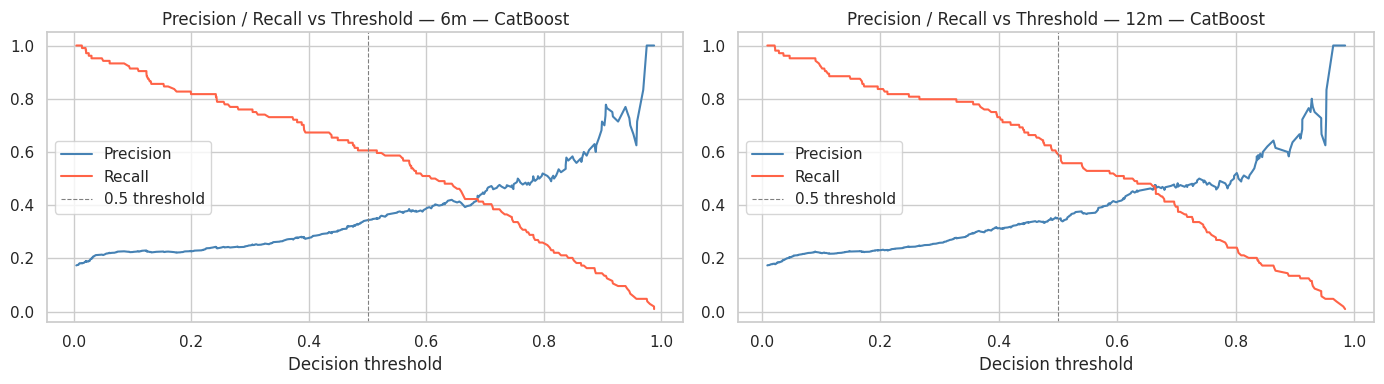

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, window in zip(axes, ("6m", "12m")):
    proba = results[window]["proba"]
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test[window], proba)
    ax.plot(thresh_arr, prec_arr[:-1], label="Precision", color="steelblue")
    ax.plot(thresh_arr, rec_arr[:-1],  label="Recall",    color="tomato")
    ax.axvline(0.5, color="gray", linestyle="--", lw=0.8, label="0.5 threshold")
    ax.set_xlabel("Decision threshold")
    ax.set_title(f"Precision / Recall vs Threshold — {window} — {results[window]['name']}")
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance

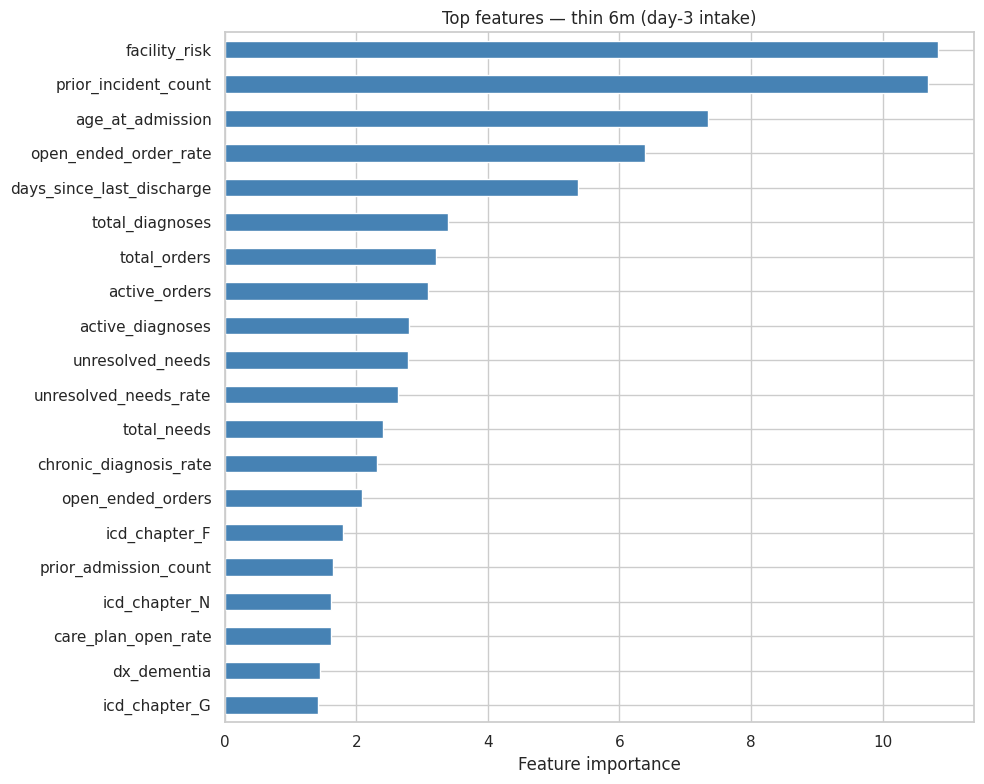

,feature,importance
0,facility_risk,10.8438
1,prior_incident_count,10.6868
2,age_at_admission,7.3449
3,open_ended_order_rate,6.3868
4,days_since_last_discharge,5.3742
...,...,...
68,order_cat_dietary_-_diet,0.0266
69,transfer_outcome_other,0.0222
70,icd_chapter_W,0.0142
71,has_overdue_review,0.0083


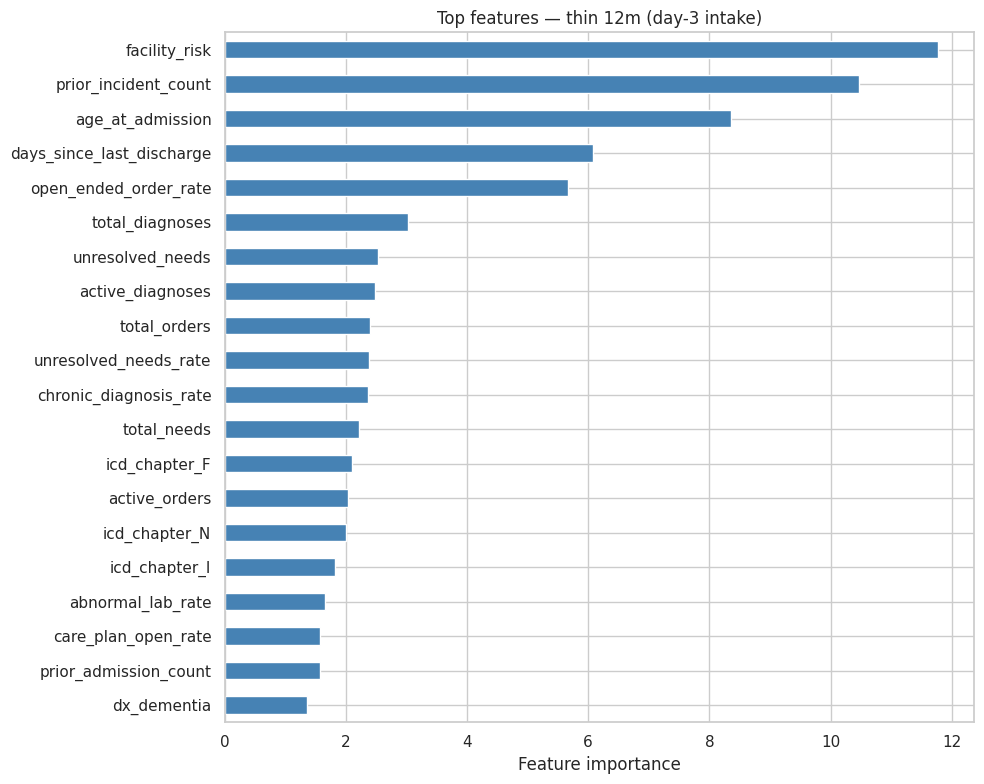

,feature,importance
0,facility_risk,11.7785
1,prior_incident_count,10.4675
2,age_at_admission,8.3521
3,days_since_last_discharge,6.0768
4,open_ended_order_rate,5.6666
...,...,...
68,"transfer_outcome_admitted,_status_uncertain",0.0776
69,icd_chapter_W,0.0568
70,has_overdue_review,0.0075
71,transfer_outcome_other,0.0000


In [25]:
from sklearn.inspection import permutation_importance

def get_importances(model, feature_cols, X, y):
    clf = model.named_steps["clf"] if hasattr(model, "named_steps") else model
    if hasattr(clf, "feature_importances_"):
        return clf.feature_importances_
    if hasattr(clf, "coef_"):
        return np.abs(clf.coef_[0])
    r = permutation_importance(model, X, y, n_repeats=10, scoring="average_precision",
                               random_state=42, n_jobs=-1)
    return r.importances_mean

for window in ("6m", "12m"):
    feats = results[window]["features"]
    importances = get_importances(results[window]["model"], feats,
                                  X_thin_test[window], y_test[window])
    imp_s = pd.Series(importances, index=feats).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 8))
    imp_s.head(20)[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Feature importance"); ax.set_title(f"Top features — thin {window} (day-3 intake)")
    plt.tight_layout(); plt.show()
    display(imp_s.reset_index().rename(columns={"index": "feature", 0: "importance"}))

## 9. Save Model

In [26]:
import json
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)
ART = Path("artifacts"); ART.mkdir(exist_ok=True)

joblib.dump(results["6m"]["features"], MODEL_DIR / "stage1_feature_cols.pkl")  # incl facility_risk

facility_export = {"intake_days": INTAKE_DAYS, "windows": {}}
for window in ("6m", "12m"):
    joblib.dump(results[window]["model"], MODEL_DIR / f"stage1_propensity_{window}.pkl")
    facility_export["windows"][window] = facility_maps[window]
    print(f"[{window}] thin  Test PR-AUC={results[window]['avg_precision']:.4f}  "
          f"Test ROC-AUC={results[window]['roc_auc']:.4f}  -> stage1_propensity_{window}.pkl")

json.dump(facility_export, open(ART / "facility_risk.json", "w"))
print("Saved facility-risk maps -> artifacts/facility_risk.json")

[6m] thin  Test PR-AUC=0.4311  Test ROC-AUC=0.7363  -> stage1_propensity_6m.pkl
[12m] thin  Test PR-AUC=0.4418  Test ROC-AUC=0.7525  -> stage1_propensity_12m.pkl
Saved facility-risk maps -> artifacts/facility_risk.json


# Part IV — Dynamic Model (Day-30 Snapshot)

Features computed from data available at day 30 of the resident's stay (admission → admission + 30 days).  
Includes vitals from the current stay. Predicts risk for the **next 7 days, 30 days, and 6 months** from the snapshot date.  
Runs every 30 days throughout the resident's stay in production.

## 12. Feature Assembly — Dynamic Model

In [27]:
# snapshot = admission + 30 days
snapshot_dates_dyn = admission_dates + pd.Timedelta(days=30)

# eligible: resident had at least 30 days of stay before data end and before discharge
discharge_ok  = discharge_dates.isna() | (pd.to_datetime(discharge_dates) >= snapshot_dates_dyn)
snapshot_ok   = snapshot_dates_dyn <= DATA_END
dyn_mask      = discharge_ok & snapshot_ok

residents_dyn       = residents[residents["resident_id"].isin(dyn_mask[dyn_mask].index)]
admission_dates_dyn = admission_dates[dyn_mask]
snapshot_dates_dyn  = snapshot_dates_dyn[dyn_mask]
discharge_dates_dyn = discharge_dates[dyn_mask]

print(f"Dynamic model population: {len(residents_dyn):,} residents "
      f"(excluded {(~dyn_mask).sum():,} with <30d stay or no room in data window)")

# run all feature functions with 30-day snapshot date
feat_dx_dyn      = feat_diagnoses(dfs["diagnoses"],          snapshot_dates_dyn)
feat_orders_dyn  = feat_physician_orders(dfs["physician_orders"], snapshot_dates_dyn)
feat_needs_dyn   = feat_needs(dfs["needs"],                  snapshot_dates_dyn)
feat_cp_dyn      = feat_care_plans(dfs["care_plans"], residents_dyn, snapshot_dates_dyn)
feat_hosp_dyn    = feat_hospital(dfs["hospital_admissions"], dfs["hospital_transfers"], snapshot_dates_dyn)
feat_meds_dyn    = feat_medications(dfs["medications"],      snapshot_dates_dyn)
feat_labs_dyn    = feat_labs(dfs["lab_reports"],             snapshot_dates_dyn)
feat_therapy_dyn = feat_therapy(dfs["therapy_tracks"],       snapshot_dates_dyn)
feat_prior_dyn   = feat_prior_incidents(incidents,           snapshot_dates_dyn)

# vitals: current stay only (admission → snapshot)
feat_vitals_dyn  = feat_vitals(dfs["vitals"], snapshot_dates_dyn,
                               start_dates=admission_dates_dyn)
print(f"Vital features: {feat_vitals_dyn.shape[1]} columns, "
      f"{feat_vitals_dyn.shape[0]:,} residents with records")

base_dyn = residents_dyn[["resident_id", "admission_date"]].set_index("resident_id")

X_dyn = base_dyn.join([
    feat_res.reindex(base_dyn.index),   # age_at_admission is static
    feat_dx_dyn, feat_orders_dyn, feat_needs_dyn, feat_cp_dyn,
    feat_hosp_dyn, feat_meds_dyn, feat_labs_dyn, feat_therapy_dyn,
    feat_prior_dyn, feat_vitals_dyn,
], how="left")

for col in ("medication_adherence", "lab_abnormality"):
    X_dyn[col] = X_dyn[col].fillna(0).astype(int)
# -1 sentinel = no prior admission (distinct from "0 days since discharge")
X_dyn["days_since_last_discharge"] = X_dyn["days_since_last_discharge"].fillna(-1)
X_dyn = X_dyn.fillna(0)

feature_cols_dyn = [c for c in X_dyn.columns if c != "admission_date"]
print(f"\nDynamic feature matrix: {X_dyn.shape[0]:,} residents × {len(feature_cols_dyn)} features")

Dynamic model population: 1,829 residents (excluded 1,171 with <30d stay or no room in data window)


Vital features: 24 columns, 950 residents with records

Dynamic feature matrix: 1,829 residents × 92 features


## 13. Target Construction — Dynamic Model

Three windows measured from the snapshot date (day 30).  
All bounded by discharge and data end — Tricura's exposure ends when the resident leaves.

In [28]:
targets_dyn = {}
for window_days, label in [(20, "20d"), (30, "30d"), (180, "6m")]:
    targets_dyn[label] = build_target(
        incidents, snapshot_dates_dyn, discharge_dates_dyn, window_days, DATA_END
    )

print(f'{"Window":>8}  {"Positives":>10}  {"Total":>8}  {"Rate":>8}')
for label, y in targets_dyn.items():
    print(f'  {label:>6}  {y.sum():>10,}  {len(y):>8,}  {100*y.mean():>7.1f}%')

  Window   Positives     Total      Rate
     20d         136     1,829      7.4%
     30d         172     1,829      9.4%
      6m         323     1,829     17.7%


## 14. Train / Test Split — Dynamic Model

In [29]:
# same admission_date cutoff as thin model for comparability
train_idx_dyn = X_dyn[X_dyn["admission_date"] <= cutoff_date].index
test_idx_dyn  = X_dyn[X_dyn["admission_date"] >  cutoff_date].index

X_train_dyn = X_dyn.loc[train_idx_dyn, feature_cols_dyn]
X_test_dyn  = X_dyn.loc[test_idx_dyn,  feature_cols_dyn]

y_train_dyn = {k: v.loc[train_idx_dyn] for k, v in targets_dyn.items()}
y_test_dyn  = {k: v.loc[test_idx_dyn]  for k, v in targets_dyn.items()}

print(f"Cutoff: {pd.to_datetime(cutoff_date).date()}")
print(f"Train: {len(X_train_dyn):,}  |  Test: {len(X_test_dyn):,}")
for k in targets_dyn:
    print(f"  y_{k}  train pos: {y_train_dyn[k].sum():,} ({100*y_train_dyn[k].mean():.1f}%)  "
          f"test pos: {y_test_dyn[k].sum():,} ({100*y_test_dyn[k].mean():.1f}%)")

Cutoff: 2024-10-02
Train: 1,510  |  Test: 319
  y_20d  train pos: 108 (7.2%)  test pos: 28 (8.8%)
  y_30d  train pos: 138 (9.1%)  test pos: 34 (10.7%)
  y_6m  train pos: 281 (18.6%)  test pos: 42 (13.2%)


## 15. CV & Training — Dynamic Model

In [30]:
cv_results_dyn = {}

for window in targets_dyn:
    cv_results_dyn[window] = {}
    pos_weight = (y_train_dyn[window] == 0).sum() / max((y_train_dyn[window] == 1).sum(), 1)
    n_pos      = y_train_dyn[window].sum()
    n_splits   = 3 if n_pos < 100 else 5
    tscv_dyn   = TimeSeriesSplit(n_splits=n_splits)

    print(f"\n=== Dynamic CV: {window} window  ({n_splits} folds, pos_weight={pos_weight:.1f}) ===")
    print(f"  {'Model':30s}  {'Mean PR-AUC':>12}  {'Std':>8}")

    for name, model in make_models(pos_weight).items():
        scores = cross_val_score(
            model, X_train_dyn, y_train_dyn[window],
            cv=tscv_dyn, scoring="average_precision", n_jobs=-1
        )
        cv_results_dyn[window][name] = scores
        print(f"  {name:30s}  {scores.mean():.4f}        ±{scores.std():.4f}  "
              f"{[round(s, 3) for s in scores]}")

print("\n--- CatBoost locked as final model for all windows ---")

# lock CatBoost for all windows regardless of CV winner
results_dyn = {}
for window in targets_dyn:
    pos_weight = (y_train_dyn[window] == 0).sum() / max((y_train_dyn[window] == 1).sum(), 1)
    model = CatBoostClassifier(
        iterations=300, auto_class_weights="Balanced", random_seed=42, verbose=0,
    )
    model.fit(X_train_dyn, y_train_dyn[window])
    proba = model.predict_proba(X_test_dyn)[:, 1]
    results_dyn[window] = {
        "model":         model,
        "name":          "CatBoost",
        "proba":         proba,
        "roc_auc":       roc_auc_score(y_test_dyn[window], proba),
        "avg_precision": average_precision_score(y_test_dyn[window], proba),
    }
    cv_ap = cv_results_dyn[window]["CatBoost"].mean()
    print(f"  [{window}] CV PR-AUC={cv_ap:.4f}  "
          f"Test PR-AUC={results_dyn[window]['avg_precision']:.4f}  "
          f"Test ROC-AUC={results_dyn[window]['roc_auc']:.4f}")


=== Dynamic CV: 20d window  (5 folds, pos_weight=13.0) ===
  Model                            Mean PR-AUC       Std


  RandomForest                    0.2196        ±0.0785  [np.float64(0.087), np.float64(0.222), np.float64(0.201), np.float64(0.323), np.float64(0.265)]


  HistGradientBoosting            0.2371        ±0.0981  [np.float64(0.062), np.float64(0.237), np.float64(0.237), np.float64(0.358), np.float64(0.292)]


  XGBoost                         0.1957        ±0.0823  [np.float64(0.101), np.float64(0.169), np.float64(0.175), np.float64(0.185), np.float64(0.349)]


  CatBoost                        0.2397        ±0.0749  [np.float64(0.105), np.float64(0.226), np.float64(0.253), np.float64(0.293), np.float64(0.321)]

=== Dynamic CV: 30d window  (5 folds, pos_weight=9.9) ===
  Model                            Mean PR-AUC       Std


...

  XGBoost                         0.3845        ±0.0766  [np.float64(0.259), np.float64(0.47), np.float64(0.336), np.float64(0.419), np.float64(0.438)]


  CatBoost                        0.4626        ±0.0651  [np.float64(0.344), np.float64(0.468), np.float64(0.461), np.float64(0.505), np.float64(0.535)]

--- CatBoost locked as final model for all windows ---


  [20d] CV PR-AUC=0.2397  Test PR-AUC=0.3159  Test ROC-AUC=0.8217


  [30d] CV PR-AUC=0.2531  Test PR-AUC=0.3759  Test ROC-AUC=0.7755


  [6m] CV PR-AUC=0.4626  Test PR-AUC=0.3416  Test ROC-AUC=0.7835


## 16. Feature Selection — Dynamic Model

Remove features that are either:
- **Low importance** — permutation importance mean ≤ 0
- **Unstable** — std > 2 × |mean| (signal-to-noise too low)

Computed on training data only. Best model retrained on cleaned feature set.

In [31]:
from sklearn.model_selection import train_test_split

def catboost_select_features(X_train, y_train, feature_cols, n_select=None):
    """
    CatBoost RecursiveByShapValues feature selection.
    Only reliable when the held-out 20% eval split has enough positives to
    rank features — applied selectively (see SELECT_WINDOWS below).
    """
    if n_select is None:
        pos_rate  = y_train.mean()
        keep_frac = max(0.30, 0.90 - pos_rate * 3.0)
        n_select  = max(10, int(len(feature_cols) * keep_frac))

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    selector = CatBoostClassifier(
        iterations=500, auto_class_weights="Balanced",
        random_seed=42, verbose=0, eval_metric="AUC",
    )
    summary = selector.select_features(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        features_for_select=list(range(len(feature_cols))),
        num_features_to_select=n_select,
        algorithm="RecursiveByShapValues",
        shap_calc_type="Approximate",
        train_final_model=False,
        logging_level="Silent",
    )
    return [feature_cols[i] for i in summary["selected_features"]]

# Per-window policy:
#  - SELECT_WINDOWS: enough positives for a reliable SHAP eval split → run selection
#  - DROP_VITAL_COUNT: monitoring-intensity features add noise over longer horizons;
#    helps 20d but hurts 30d/6m, so drop them there
SELECT_WINDOWS    = {"6m"}
DROP_VITAL_COUNT  = {"30d", "6m"}

vital_count_cols = [c for c in feature_cols_dyn if c.startswith("vital_count_")]

for window, res in results_dyn.items():
    print(f"\n{'='*55} {window}")

    base_feats = feature_cols_dyn
    if window in DROP_VITAL_COUNT:
        base_feats = [c for c in base_feats if c not in vital_count_cols]
        print(f"  Dropped {len(vital_count_cols)} vital_count_* features (long-horizon noise)")

    if window in SELECT_WINDOWS:
        selected = catboost_select_features(X_train_dyn, y_train_dyn[window], base_feats)
        print(f"  Feature selection applied — kept {len(selected)}/{len(base_feats)} "
              f"({100*len(selected)/len(base_feats):.0f}%)")
    else:
        selected = base_feats
        print(f"  Feature selection skipped (sparse window) — using {len(selected)} features")

    final_model = CatBoostClassifier(
        iterations=500, auto_class_weights="Balanced", random_seed=42, verbose=0,
    )
    final_model.fit(X_train_dyn[selected], y_train_dyn[window])
    proba = final_model.predict_proba(X_test_dyn[selected])[:, 1]

    ap  = average_precision_score(y_test_dyn[window], proba)
    auc = roc_auc_score(y_test_dyn[window], proba)
    print(f"  Before → PR-AUC={res['avg_precision']:.4f}  ROC-AUC={res['roc_auc']:.4f}")
    print(f"  After  → PR-AUC={ap:.4f}  ROC-AUC={auc:.4f}")

    results_dyn[window].update({
        "model":         final_model,
        "name":          "CatBoost",
        "features":      selected,
        "proba":         proba,
        "avg_precision": ap,
        "roc_auc":       auc,
    })


======================================================= 20d
  Feature selection skipped (sparse window) — using 92 features


  Before → PR-AUC=0.3159  ROC-AUC=0.8217
  After  → PR-AUC=0.3646  ROC-AUC=0.8073

======================================================= 30d
  Dropped 8 vital_count_* features (long-horizon noise)
  Feature selection skipped (sparse window) — using 84 features


  Before → PR-AUC=0.3759  ROC-AUC=0.7755
  After  → PR-AUC=0.3417  ROC-AUC=0.7799

======================================================= 6m
  Dropped 8 vital_count_* features (long-horizon noise)


  Feature selection applied — kept 28/84 (33%)


  Before → PR-AUC=0.3416  ROC-AUC=0.7835
  After  → PR-AUC=0.3586  ROC-AUC=0.8011


n_windows = len(results_dyn)
fig, axes = plt.subplots(n_windows, 2, figsize=(14, 5 * n_windows))
if n_windows == 1:
    axes = [axes]

for row, (window, res) in enumerate(results_dyn.items()):
    proba    = res["proba"]
    baseline = y_test_dyn[window].mean()

    prec, rec, _ = precision_recall_curve(y_test_dyn[window], proba)
    axes[row][0].plot(rec, prec, color="steelblue", lw=2,
                      label=f"{res['name']} (AP={res['avg_precision']:.3f})")
    axes[row][0].axhline(baseline, color="k", linestyle="--", lw=0.8,
                         label=f"Baseline ({baseline:.2f})")
    axes[row][0].set_title(f"PR Curve — {window} window  ({len(res['features'])} features)")
    axes[row][0].set_xlabel("Recall"); axes[row][0].set_ylabel("Precision")
    axes[row][0].legend()

    fpr, tpr, _ = roc_curve(y_test_dyn[window], proba)
    axes[row][1].plot(fpr, tpr, color="darkorange", lw=2,
                      label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
    axes[row][1].plot([0, 1], [0, 1], "k--", lw=0.8)
    axes[row][1].set_title(f"ROC Curve — {window} window")
    axes[row][1].set_xlabel("FPR"); axes[row][1].set_ylabel("TPR")
    axes[row][1].legend()

plt.tight_layout()
plt.show()

for window, res in results_dyn.items():
    y_pred = (res["proba"] >= 0.5).astype(int)
    print(f"\n{'='*50}  {window} window  {'='*50}")
    print(f"Best model: {res['name']}  |  Features: {len(res['features'])}\n")
    print(classification_report(y_test_dyn[window], y_pred,
                                target_names=["No Incident", "Had Incident"]))

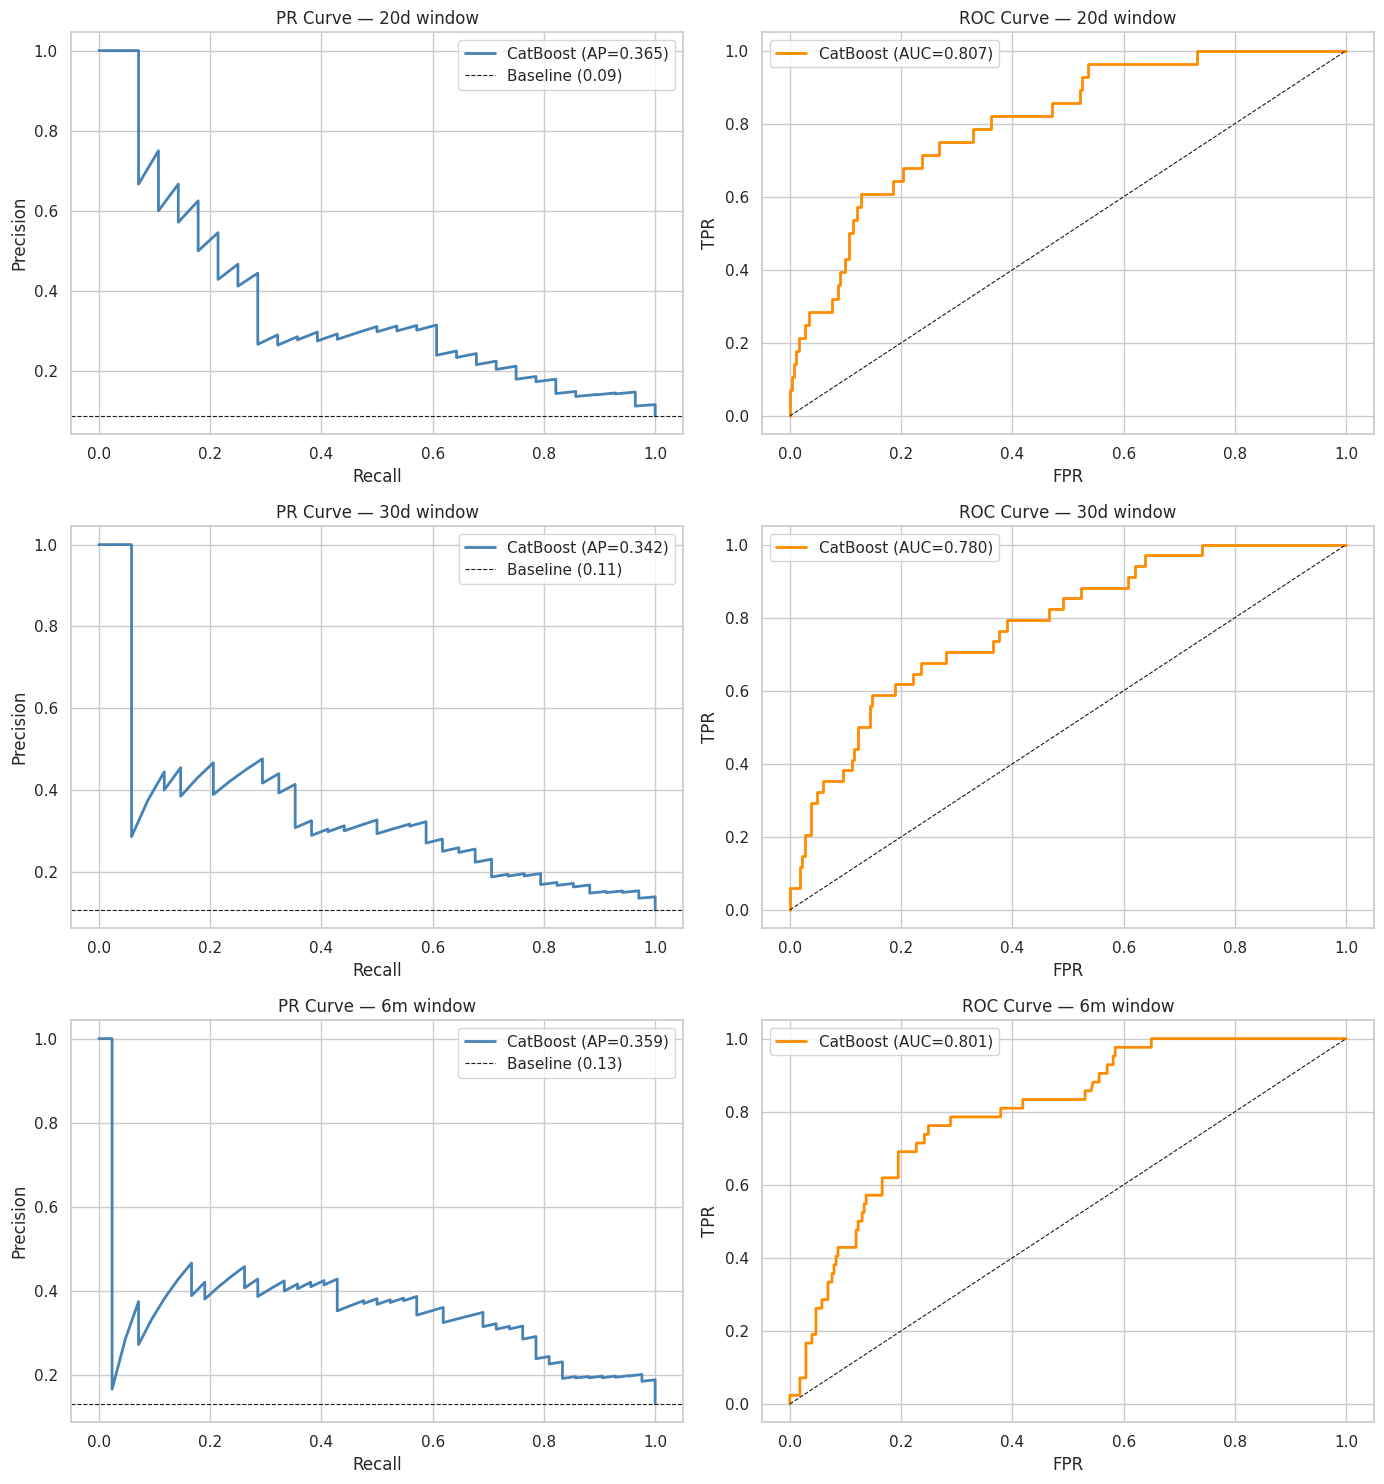


==================================================  20d window  ==================================================
Best model: CatBoost

              precision    recall  f1-score   support

 No Incident       0.93      0.96      0.94       291
Had Incident       0.38      0.29      0.33        28

    accuracy                           0.90       319
   macro avg       0.66      0.62      0.64       319
weighted avg       0.88      0.90      0.89       319


==================================================  30d window  ==================================================
Best model: CatBoost

              precision    recall  f1-score   support

 No Incident       0.92      0.92      0.92       285
Had Incident       0.33      0.35      0.34        34

    accuracy                           0.86       319
   macro avg       0.63      0.63      0.63       319
weighted avg       0.86      0.86      0.86       319


==================================================  6m window  ======

In [32]:
n_windows = len(results_dyn)
fig, axes = plt.subplots(n_windows, 2, figsize=(14, 5 * n_windows))
if n_windows == 1:
    axes = [axes]

for row, (window, res) in enumerate(results_dyn.items()):
    proba    = res["proba"]
    baseline = y_test_dyn[window].mean()

    prec, rec, _ = precision_recall_curve(y_test_dyn[window], proba)
    axes[row][0].plot(rec, prec, color="steelblue", lw=2,
                      label=f"{res['name']} (AP={res['avg_precision']:.3f})")
    axes[row][0].axhline(baseline, color="k", linestyle="--", lw=0.8,
                         label=f"Baseline ({baseline:.2f})")
    axes[row][0].set_title(f"PR Curve — {window} window")
    axes[row][0].set_xlabel("Recall"); axes[row][0].set_ylabel("Precision")
    axes[row][0].legend()

    fpr, tpr, _ = roc_curve(y_test_dyn[window], proba)
    axes[row][1].plot(fpr, tpr, color="darkorange", lw=2,
                      label=f"{res['name']} (AUC={res['roc_auc']:.3f})")
    axes[row][1].plot([0, 1], [0, 1], "k--", lw=0.8)
    axes[row][1].set_title(f"ROC Curve — {window} window")
    axes[row][1].set_xlabel("FPR"); axes[row][1].set_ylabel("TPR")
    axes[row][1].legend()

plt.tight_layout()
plt.show()

for window, res in results_dyn.items():
    y_pred = (res["proba"] >= 0.5).astype(int)
    print(f"\n{'='*50}  {window} window  {'='*50}")
    print(f"Best model: {res['name']}\n")
    print(classification_report(y_test_dyn[window], y_pred,
                                target_names=["No Incident", "Had Incident"]))

## 17. Feature Importance — Dynamic Model


[20d] Feature importances — CatBoost  (92 features)


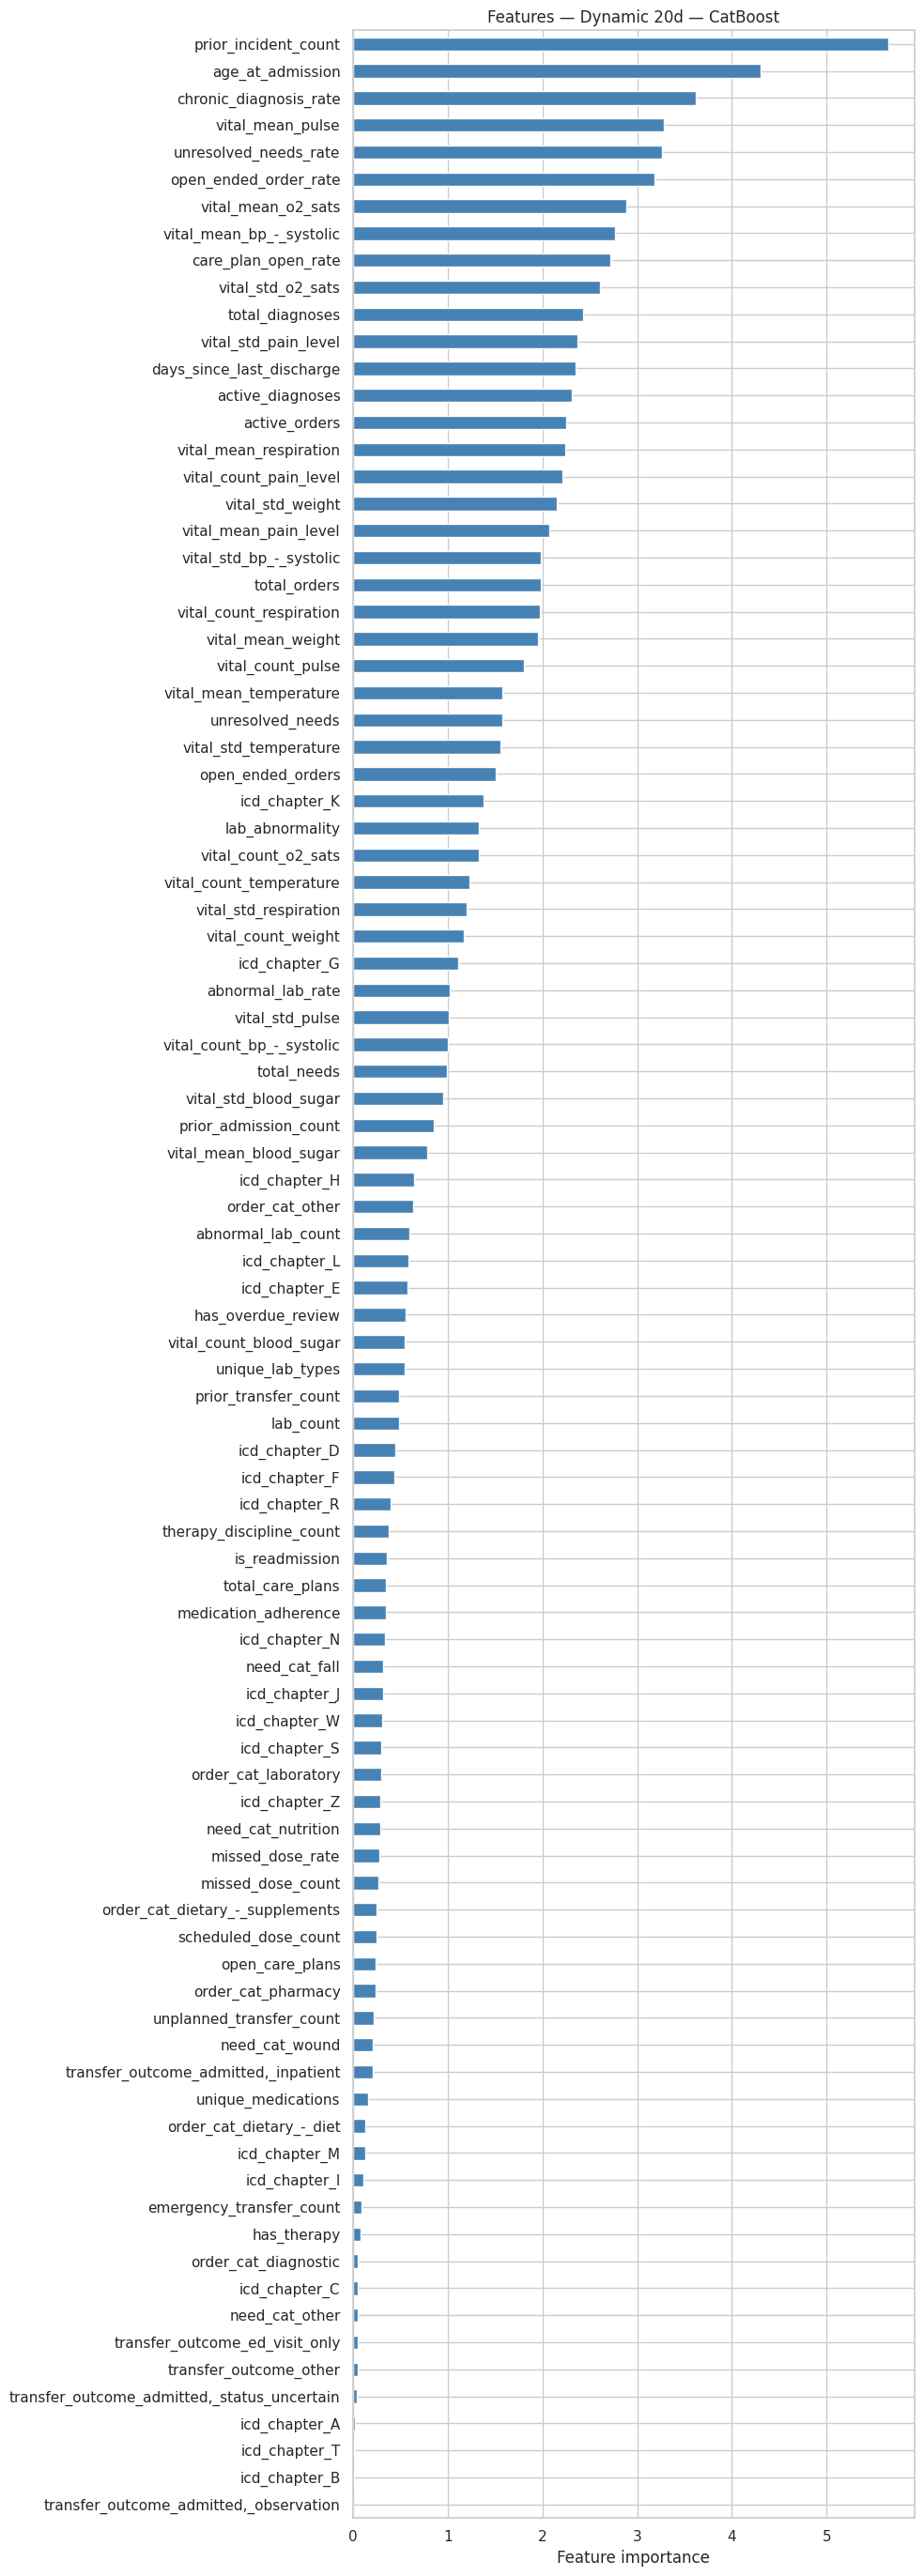

,feature,importance
0,prior_incident_count,5.6458
1,age_at_admission,4.2982
2,chronic_diagnosis_rate,3.6152
3,vital_mean_pulse,3.2836
4,unresolved_needs_rate,3.2639
...,...,...
87,"transfer_outcome_admitted,_status_uncertain",0.0441
88,icd_chapter_A,0.0215
89,icd_chapter_T,0.0164
90,icd_chapter_B,0.0105



[30d] Feature importances — CatBoost  (84 features)


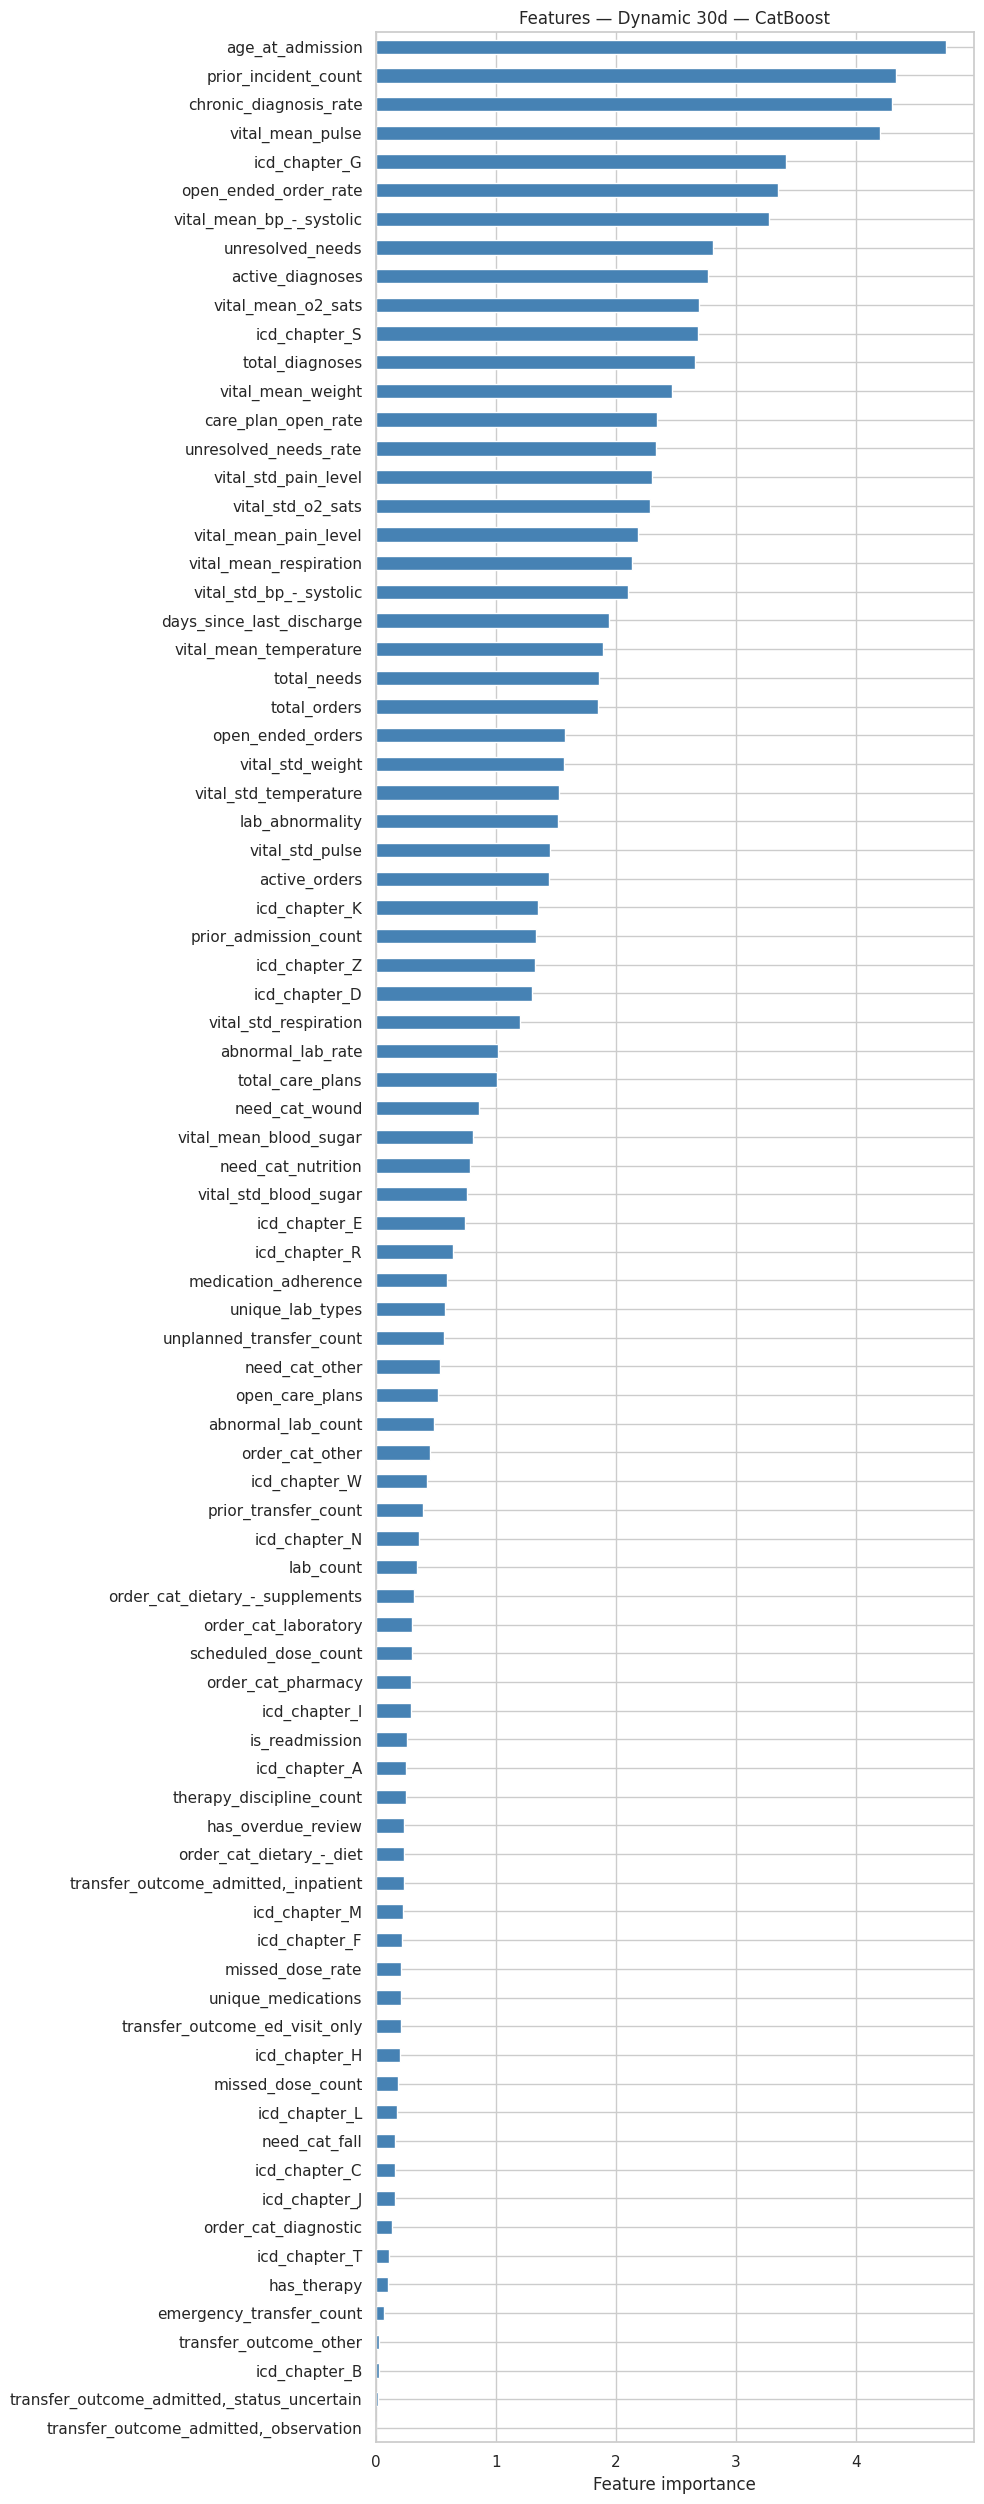

,feature,importance
0,age_at_admission,4.7483
1,prior_incident_count,4.3376
2,chronic_diagnosis_rate,4.3061
3,vital_mean_pulse,4.2036
4,icd_chapter_G,3.4209
...,...,...
79,emergency_transfer_count,0.0642
80,transfer_outcome_other,0.0303
81,icd_chapter_B,0.0233
82,"transfer_outcome_admitted,_status_uncertain",0.0192



[6m] Feature importances — CatBoost  (28 features)


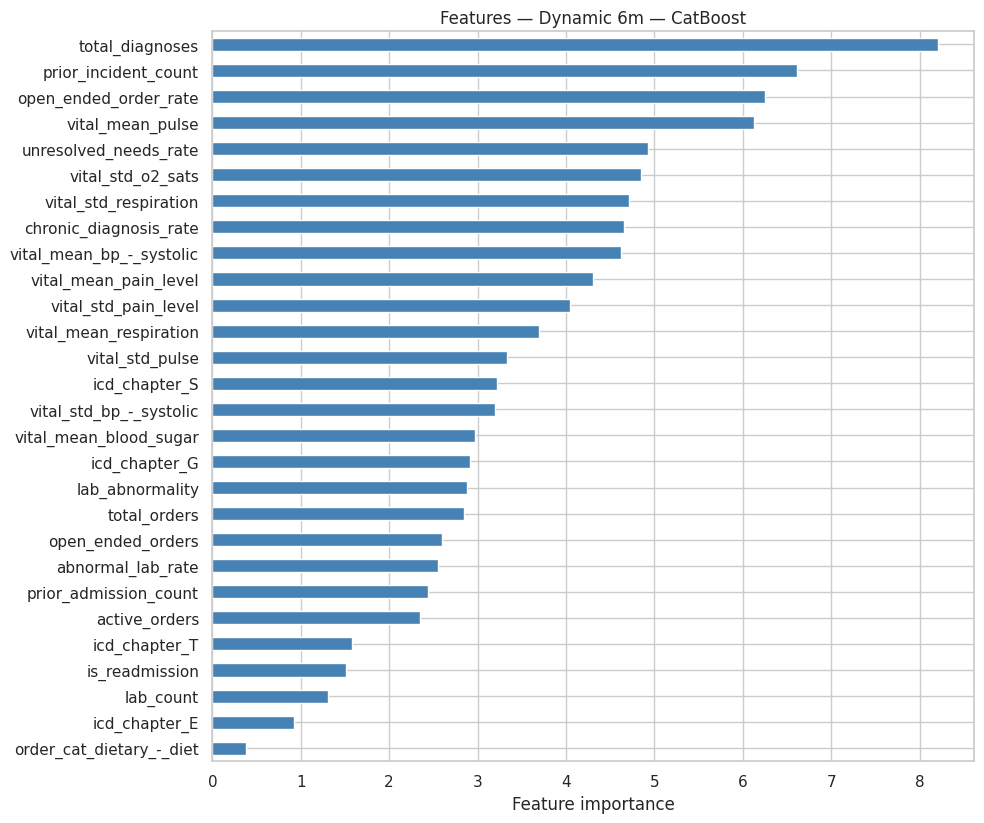

,feature,importance
0,total_diagnoses,8.2046
1,prior_incident_count,6.6154
2,open_ended_order_rate,6.2484
3,vital_mean_pulse,6.1223
4,unresolved_needs_rate,4.9316
5,vital_std_o2_sats,4.8432
6,vital_std_respiration,4.7106
7,chronic_diagnosis_rate,4.6575
8,vital_mean_bp_-_systolic,4.6254
9,vital_mean_pain_level,4.3017


In [33]:
for window, res in results_dyn.items():
    feats = res["features"]
    print(f"\n[{window}] Feature importances — {res['name']}  ({len(feats)} features)")
    importances = get_importances(res["model"], feats,
                                  X_test_dyn[feats], y_test_dyn[window])
    imp_s = pd.Series(importances, index=feats).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(5, 0.3 * len(feats))))
    imp_s[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Feature importance")
    ax.set_title(f"Features — Dynamic {window} — {res['name']}")
    plt.tight_layout()
    plt.show()

    display(imp_s.reset_index().rename(columns={"index": "feature", 0: "importance"}))

## 18. Save — Dynamic Model

In [34]:
# save feature list per window (each window may have different selected features)
feature_cols_per_window = {w: res["features"] for w, res in results_dyn.items()}
joblib.dump(feature_cols_per_window, MODEL_DIR / "dynamic_feature_cols.pkl")

for window, res in results_dyn.items():
    path = MODEL_DIR / f"dynamic_{window}.pkl"
    joblib.dump(res["model"], path)
    cv_ap = cv_results_dyn[window][res["name"]].mean()
    print(f"[dyn {window}] {res['name']:30s}  "
          f"CV PR-AUC={cv_ap:.4f}  "
          f"Test PR-AUC={res['avg_precision']:.4f}  "
          f"Test ROC-AUC={res['roc_auc']:.4f}  "
          f"features={len(res['features'])}  → {path}")

print("\n--- Saved models ---")
for p in sorted(MODEL_DIR.glob("*.pkl")):
    print(f"  {p}")

[dyn 20d] CatBoost                        CV PR-AUC=0.2397  Test PR-AUC=0.3646  Test ROC-AUC=0.8073  features=92  → models/dynamic_20d.pkl
[dyn 30d] CatBoost                        CV PR-AUC=0.2531  Test PR-AUC=0.3417  Test ROC-AUC=0.7799  features=84  → models/dynamic_30d.pkl
[dyn 6m] CatBoost                        CV PR-AUC=0.4626  Test PR-AUC=0.3586  Test ROC-AUC=0.8011  features=28  → models/dynamic_6m.pkl

--- Saved models ---
  models/dynamic_20d.pkl
  models/dynamic_30d.pkl
  models/dynamic_6m.pkl
  models/dynamic_feature_cols.pkl
  models/stage1_feature_cols.pkl
  models/stage1_propensity_12m.pkl
  models/stage1_propensity_6m.pkl
  models/stage3_cost_map.pkl
  models/stage3_feature_cols.pkl
  models/stage3_incident_type.pkl


## 19. Experiment — Do `vital_count_*` Features Help?

The `vital_count_*` features measure monitoring intensity (how often vitals were taken), not the resident's physiology. Compare each window's model with vs without them.

In [35]:
vital_count_cols = [c for c in feature_cols_dyn if c.startswith("vital_count_")]
print(f"Testing removal of {len(vital_count_cols)} vital_count_* features\n")

print(f"{'Window':>7} | {'WITH counts':^21} | {'WITHOUT counts':^21}")
print(f"{'':7} | {'PR-AUC':>9} {'ROC-AUC':>10} | {'PR-AUC':>9} {'ROC-AUC':>10}")
print("-" * 56)
for window, res in results_dyn.items():
    feats_without = [c for c in res["features"] if c not in vital_count_cols]

    m = CatBoostClassifier(iterations=500, auto_class_weights="Balanced",
                           random_seed=42, verbose=0)
    m.fit(X_train_dyn[feats_without], y_train_dyn[window])
    p = m.predict_proba(X_test_dyn[feats_without])[:, 1]
    ap_wo  = average_precision_score(y_test_dyn[window], p)
    auc_wo = roc_auc_score(y_test_dyn[window], p)

    print(f"{window:>7} | {res['avg_precision']:>9.4f} {res['roc_auc']:>10.4f} | "
          f"{ap_wo:>9.4f} {auc_wo:>10.4f}")

Testing removal of 8 vital_count_* features

 Window |      WITH counts      |    WITHOUT counts    
        |    PR-AUC    ROC-AUC |    PR-AUC    ROC-AUC
--------------------------------------------------------


    20d |    0.3646     0.8073 |    0.3090     0.7968


    30d |    0.3417     0.7799 |    0.3417     0.7799


     6m |    0.3586     0.8011 |    0.3586     0.8011


# Part V — Incident-Type & Expected-Cost Model (Stage 3)

Predict which **type** of incident a resident is at risk of, which maps to the README cost table.
Trained at the **incident level** (one row per incident, ~3,382 rows) — far more data than the
per-window conditional approach. Features are the resident's profile **as of each incident's date**
(leakage-safe). Combined with Stage 1's P(incident), this yields an expected-cost score per resident.

5 of 6 README cost categories map to `incident_type`; RTH ($20k) lives in hospital_transfers, not
incidents, so it is out of scope here. Rare types (Med Error, Choking, Elopement) are folded into 'Other'.

In [36]:
# ---- Incident-level feature engineering (as-of each incident's occurred_at) ----
incs = incidents[["incident_id", "resident_id", "occurred_at", "incident_type"]].copy()
incs["occurred_at"] = pd.to_datetime(incs["occurred_at"])

def count_before(events_df, date_col, name):
    """Count rows per incident where the event predates the incident's occurred_at."""
    e = events_df.dropna(subset=["resident_id"])[["resident_id", date_col]].copy()
    e[date_col] = pd.to_datetime(e[date_col])
    m = incs[["incident_id", "resident_id", "occurred_at"]].merge(e, on="resident_id", how="left")
    m = m[m[date_col] < m["occurred_at"]]
    return m.groupby("incident_id").size().rename(name)

F = pd.DataFrame(index=incs.set_index("incident_id").index)

# age at incident
dob = pd.to_datetime(residents.set_index("resident_id")["date_of_birth"])
F["age_at_incident"] = (incs.set_index("incident_id")["occurred_at"]
                        - incs.set_index("incident_id")["resident_id"].map(dob)).dt.days / 365.25

# prior incidents overall and by type (type-specific recurrence is a strong signal)
pair = incs.merge(
    incs[["resident_id", "occurred_at", "incident_type"]].rename(
        columns={"occurred_at": "prior_at", "incident_type": "prior_type"}),
    on="resident_id")
pair = pair[pair["prior_at"] < pair["occurred_at"]]
F["prior_incident_count"] = pair.groupby("incident_id").size()
for t in ["Fall", "Wound", "Altercation"]:
    F[f"prior_{t.lower()}_count"] = pair[pair["prior_type"] == t].groupby("incident_id").size()

# clinical history before the incident
dx = dfs["diagnoses"][~dfs["diagnoses"]["strikeout"]]
F["dx_count"] = count_before(dx, "created_at", "dx_count")
# diagnosis chapters relevant to incident type: M=musculoskeletal, L=skin, F=mental/behavioural,
# G=nervous, N=genitourinary, E=endocrine, I=circulatory
dxc = dx.copy(); dxc["chap"] = dxc["icd_10_code"].str[:1]
for ch in ["M", "L", "F", "G", "N", "E", "I"]:
    F[f"dx_chap_{ch}"] = count_before(dxc[dxc["chap"] == ch], "created_at", f"dx_chap_{ch}")

F["prior_admission_count"] = count_before(dfs["hospital_admissions"], "effective_date", "x")
F["prior_transfer_count"]  = count_before(dfs["hospital_transfers"], "effective_date", "x")
F["order_count"]           = count_before(dfs["physician_orders"], "ordered_at", "x")
F["need_count"]            = count_before(dfs["needs"][~dfs["needs"]["strikeout"]], "initiated_at", "x")
# fall-related need flag (strong fall predictor)
needs_fall = dfs["needs"][(~dfs["needs"]["strikeout"]) & (dfs["needs"]["need_category"] == "Fall")]
F["need_fall_count"] = count_before(needs_fall, "initiated_at", "x")

F = F.fillna(0)
print(f"Incident-level feature matrix: {F.shape[0]:,} incidents x {F.shape[1]} features")
F.head(3)

Incident-level feature matrix: 3,382 incidents x 18 features


,age_at_incident,prior_incident_count,prior_fall_count,prior_wound_count,prior_altercation_count,dx_count,dx_chap_M,dx_chap_L,dx_chap_F,dx_chap_G,dx_chap_N,dx_chap_E,dx_chap_I,prior_admission_count,prior_transfer_count,order_count,need_count,need_fall_count
incident_id,,,,,,,,,,,,,,,,,,
0d32dafc-e91c-5360-aefd-55e0f98943d6,77.9165,1.0000,0.0000,1.0000,0.0000,15.0000,1.0000,0.0000,2.0000,0.0000,0.0000,3.0000,2.0000,0.0000,1.0000,24.0000,63.0000,6.0000
447f3407-8ccb-5e86-8469-7e0af5314ade,92.8487,1.0000,1.0000,0.0000,0.0000,20.0000,1.0000,0.0000,2.0000,2.0000,1.0000,2.0000,2.0000,0.0000,0.0000,21.0000,16.0000,14.0000
4860a3b6-9edf-53ec-841a-1c5a15b84709,86.9815,0.0000,0.0000,0.0000,0.0000,22.0000,0.0000,0.0000,2.0000,1.0000,0.0000,2.0000,4.0000,0.0000,0.0000,15.0000,0.0000,0.0000


In [37]:
# ---- Consolidated target + cost map ----
def consolidate_type(t):
    return t if t in ("Fall", "Wound", "Altercation") else "Other"

y_type = incs.set_index("incident_id")["incident_type"].map(consolidate_type)

# README costs; 'Other' = count-weighted avg of Med Error/Choking/Elopement
README_COST = {"Fall": 3500, "Wound": 4000, "Altercation": 2500,
               "Medication Error": 5000, "Elopement": 2500, "Choking": 2500}
other_types = incs[~incs["incident_type"].isin(["Fall", "Wound", "Altercation"])]["incident_type"]
other_cost = float(np.mean([README_COST.get(t, 2500) for t in other_types]))
COST = {"Fall": 3500, "Wound": 4000, "Altercation": 2500, "Other": round(other_cost)}

print("Class distribution:")
print(y_type.value_counts().to_string())
print(f"\nCost map: {COST}")

Class distribution:
incident_type
Fall           2505
Wound           589
Altercation     228
Other            60

Cost map: {'Fall': 3500, 'Wound': 4000, 'Altercation': 2500, 'Other': 4333}


In [38]:
# ---- Time-based split on incident date ----
order = incs.set_index("incident_id")["occurred_at"].sort_values().index
cut   = int(len(order) * 0.8)
cut_date = incs.set_index("incident_id").loc[order[cut], "occurred_at"]

occ = incs.set_index("incident_id")["occurred_at"]
tr_idx = occ[occ <= cut_date].index
te_idx = occ[occ >  cut_date].index

Xtr_t, Xte_t = F.loc[tr_idx], F.loc[te_idx]
ytr_t, yte_t = y_type.loc[tr_idx], y_type.loc[te_idx]

print(f"Cutoff: {pd.to_datetime(cut_date).date()}")
print(f"Train: {len(Xtr_t):,}  Test: {len(Xte_t):,}")
print("\nTrain class mix:"); print(ytr_t.value_counts().to_string())
print("\nTest class mix:");  print(yte_t.value_counts().to_string())

Cutoff: 2024-10-19
Train: 2,706  Test: 676

Train class mix:
incident_type
Fall           2018
Wound           454
Altercation     181
Other            53

Test class mix:
incident_type
Fall           487
Wound          135
Altercation     47
Other            7


              precision    recall  f1-score   support

        Fall       0.81      0.75      0.78       487
       Wound       0.39      0.48      0.43       135
 Altercation       0.35      0.40      0.37        47
       Other       0.25      0.14      0.18         7

    accuracy                           0.67       676
   macro avg       0.45      0.44      0.44       676
weighted avg       0.69      0.67      0.67       676

Macro-F1: 0.4411
Always-predict-Fall accuracy (baseline): 0.7204
Model accuracy: 0.6657


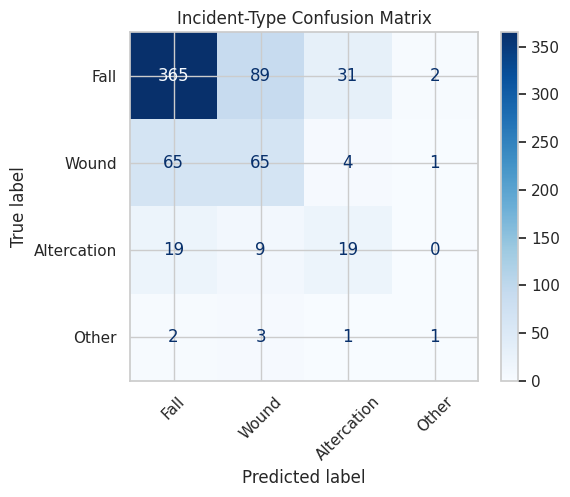

In [39]:
# ---- CatBoost multiclass ----
type_model = CatBoostClassifier(
    iterations=500, auto_class_weights="Balanced",
    random_seed=42, verbose=0, loss_function="MultiClass",
)
type_model.fit(Xtr_t, ytr_t)
pred_t = type_model.predict(Xte_t).ravel()

from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
classes = ["Fall", "Wound", "Altercation", "Other"]

print(classification_report(yte_t, pred_t, labels=classes, zero_division=0))
macro = f1_score(yte_t, pred_t, labels=classes, average="macro", zero_division=0)
baseline_acc = (yte_t == "Fall").mean()
print(f"Macro-F1: {macro:.4f}")
print(f"Always-predict-Fall accuracy (baseline): {baseline_acc:.4f}")
print(f"Model accuracy: {(pred_t == yte_t).mean():.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(yte_t, pred_t, labels=classes,
                                        cmap="Blues", ax=ax, xticks_rotation=45)
ax.set_title("Incident-Type Confusion Matrix")
plt.tight_layout(); plt.show()

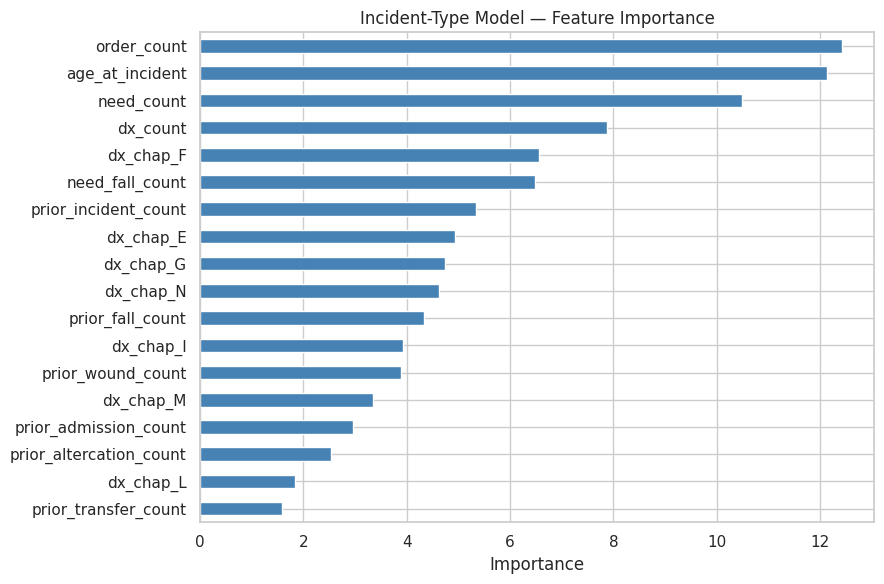

,feature,importance
0,order_count,12.4185
1,age_at_incident,12.1255
2,need_count,10.4926
3,dx_count,7.8752
4,dx_chap_F,6.5511
5,need_fall_count,6.4902
6,prior_incident_count,5.3316
7,dx_chap_E,4.9326
8,dx_chap_G,4.7365
9,dx_chap_N,4.6316


In [40]:
# ---- Feature importance ----
imp = pd.Series(type_model.get_feature_importance(), index=F.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
imp[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_title("Incident-Type Model — Feature Importance"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()
display(imp.reset_index().rename(columns={"index": "feature", 0: "importance"}))

In [41]:
# ---- Expected cost per incident: E[cost] = sum_type P(type) * cost[type] ----
proba_t = type_model.predict_proba(Xte_t)
model_classes = list(type_model.classes_)
cost_vec = np.array([COST[c] for c in model_classes])
exp_cost = proba_t @ cost_vec

ec = pd.Series(exp_cost, index=Xte_t.index)
print("Expected cost per incident (test set):")
print(ec.describe().round(0).to_string())

# realised cost using true type, for comparison
realised = yte_t.map(COST)
print(f"\nMean predicted E[cost/incident]: \${ec.mean():,.0f}")
print(f"Mean realised cost/incident:     \${realised.mean():,.0f}")

print("""
To get expected cost per RESIDENT at the day-30 snapshot:
    expected_cost = P(incident in window)  [dynamic model]
                  x E[cost | incident]      [this model, applied to snapshot features]
The product ranks residents by dollar-denominated risk for intervention targeting.""")

Expected cost per incident (test set):
count    676.0000
mean    3548.0000
std      287.0000
min     2531.0000
25%     3493.0000
50%     3560.0000
75%     3711.0000
max     4285.0000

Mean predicted E[cost/incident]: \$3,548
Mean realised cost/incident:     \$3,539

To get expected cost per RESIDENT at the day-30 snapshot:
    expected_cost = P(incident in window)  [dynamic model]
                  x E[cost | incident]      [this model, applied to snapshot features]
The product ranks residents by dollar-denominated risk for intervention targeting.


In [42]:
joblib.dump(type_model, MODEL_DIR / "stage3_incident_type.pkl")
joblib.dump(list(F.columns), MODEL_DIR / "stage3_feature_cols.pkl")
joblib.dump(COST, MODEL_DIR / "stage3_cost_map.pkl")
print("Saved Stage 3 incident-type model + feature list + cost map")
print(f"  Macro-F1={macro:.4f}  vs baseline acc={baseline_acc:.4f}")

Saved Stage 3 incident-type model + feature list + cost map
  Macro-F1=0.4411  vs baseline acc=0.7204


# Part VI — Export Serving Artifacts

Dump everything the API needs: per-resident feature matrix (demo lookups), training reference
distributions (drift detection), per-window risk-tier cutoffs, and the cost map.

In [43]:
import json
ART = Path("artifacts"); ART.mkdir(exist_ok=True)

# 1. per-resident dynamic feature matrix (full set) for demo lookups by resident_id
X_dyn[feature_cols_dyn].to_parquet(ART / "serving_features.parquet")

# 2. training reference distributions for drift (PSI) — per dynamic feature
reference = {}
for col in feature_cols_dyn:
    s = X_train_dyn[col].astype(float)
    edges = np.unique(np.quantile(s, np.linspace(0, 1, 11)))
    rec = {"mean": float(s.mean()), "std": float(s.std()),
           "min": float(s.min()), "max": float(s.max())}
    if len(edges) < 2:  # constant / degenerate feature — excluded from PSI
        rec["bin_edges"] = []; rec["expected_fracs"] = []
    else:
        # store the TRAINING proportion per bin (deciles collapse for skewed/binary
        # features, so bins are not equal-mass — PSI must compare against these, not a
        # uniform 0.1 assumption, or in-distribution data falsely flags as drift)
        counts, _ = np.histogram(s, bins=edges)
        rec["bin_edges"] = edges.tolist()
        rec["expected_fracs"] = (counts / counts.sum()).tolist()
    reference[col] = rec
json.dump(reference, open(ART / "reference_stats.json", "w"), indent=1)

# 3. per-window risk-tier cutoffs (from train predicted-probability quantiles)
tiers = {}
for w, res in results_dyn.items():
    p = res["model"].predict_proba(X_train_dyn[res["features"]])[:, 1]
    tiers[w] = {"medium": float(np.quantile(p, 0.60)), "high": float(np.quantile(p, 0.85))}

# 4. mean cost per incident (README cost map, consolidated types)
type_consol = incidents["incident_type"].map(
    lambda t: t if t in ("Fall", "Wound", "Altercation") else "Other")
mean_cost = float(type_consol.map(COST).mean())

# 5. per-window PR-AUC retraining floor, baseline-relative.
#    PR-AUC of a random model == the positive rate (prevalence), so the floor is set
#    halfway between that baseline and the launch performance: floor = base + 0.5*(launch - base).
#    Triggers retraining once the model has lost ~half its skill — auto-calibrated per window.
base_rate    = {w: float(y_train_dyn[w].mean()) for w in results_dyn}
launch_prauc = {w: float(results_dyn[w]["avg_precision"]) for w in results_dyn}
pr_auc_floor = {w: round(base_rate[w] + 0.5 * (launch_prauc[w] - base_rate[w]), 4)
                for w in results_dyn}

meta = {
    "windows": list(results_dyn.keys()),
    "risk_tiers": tiers,
    "mean_cost_per_incident": mean_cost,
    "cost_map": COST,
    "train_positive_rate": base_rate,
    "launch_pr_auc": launch_prauc,
    "pr_auc_floor": pr_auc_floor,
    "stage3_features": list(F.columns),
}
json.dump(meta, open(ART / "serving_meta.json", "w"), indent=1)

print("Exported:", sorted(p.name for p in ART.iterdir()))
print(f"Mean cost/incident: ${mean_cost:,.0f}")
print("Per-window PR-AUC retraining floors (baseline-relative):")
for w in results_dyn:
    print(f"  {w}: baseline={base_rate[w]:.3f}  launch={launch_prauc[w]:.3f}  floor={pr_auc_floor[w]:.3f}")

Exported: ['facility_risk.json', 'reference_stats.json', 'serving_features.parquet', 'serving_meta.json']
Mean cost/incident: $3,534
Per-window PR-AUC retraining floors (baseline-relative):
  20d: baseline=0.072  launch=0.365  floor=0.218
  30d: baseline=0.091  launch=0.342  floor=0.216
  6m: baseline=0.186  launch=0.359  floor=0.272


# Experiment — Does facility risk help the dynamic (day-30) model?

The facility-risk lever lifted the thin model a lot, but the dynamic model already has strong
resident-level signal (prior incidents, transfers, vital variability), so facility risk may be
redundant here. Test it per window, before/after, on the same test split.

Facility risk is **out-of-fold target-encoded** on the training set (5-fold) to avoid leakage —
each training row gets its facility's rate computed from the *other* folds; test rows use the
full-train rate.


In [44]:
from sklearn.model_selection import KFold

fac_dyn = residents.set_index("resident_id")["facility_id"].reindex(X_dyn.index)

def oof_facility_risk(y_train_series, smoothing=10.0):
    """Out-of-fold smoothed target encoding on train; full-train rate for test rows."""
    fac_tr = fac_dyn.loc[train_idx_dyn]
    glob = y_train_series.mean()
    oof = pd.Series(index=train_idx_dyn, dtype=float)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for fit_pos, val_pos in kf.split(train_idx_dyn):
        fit_idx = train_idx_dyn[fit_pos]
        val_idx = train_idx_dyn[val_pos]
        g = pd.DataFrame({"fac": fac_tr.loc[fit_idx], "y": y_train_series.loc[fit_idx]}) \
            .groupby("fac")["y"].agg(["sum", "count"])
        rate = (g["sum"] + smoothing * glob) / (g["count"] + smoothing)
        oof.loc[val_idx] = fac_tr.loc[val_idx].map(rate).fillna(glob)
    # test rows: rate from full training set
    g = pd.DataFrame({"fac": fac_tr, "y": y_train_series}).groupby("fac")["y"].agg(["sum", "count"])
    full_rate = (g["sum"] + smoothing * glob) / (g["count"] + smoothing)
    test_vals = fac_dyn.loc[test_idx_dyn].map(full_rate).fillna(glob)
    return oof, test_vals

print(f"{'Window':>7} | {'baseline (current)':^22} | {'+ facility_risk':^22}")
print(f"{'':7} | {'PR-AUC':>9} {'ROC-AUC':>10} | {'PR-AUC':>9} {'ROC-AUC':>10}")
print("-" * 60)
for window, res in results_dyn.items():
    feats = res["features"]
    oof_tr, te_vals = oof_facility_risk(y_train_dyn[window])

    Xtr = X_train_dyn[feats].copy(); Xtr["facility_risk"] = oof_tr
    Xte = X_test_dyn[feats].copy();  Xte["facility_risk"] = te_vals

    m = CatBoostClassifier(iterations=500, auto_class_weights="Balanced",
                           random_seed=42, verbose=0)
    m.fit(Xtr, y_train_dyn[window])
    p = m.predict_proba(Xte)[:, 1]
    ap_new, auc_new = average_precision_score(y_test_dyn[window], p), roc_auc_score(y_test_dyn[window], p)

    print(f"{window:>7} | {res['avg_precision']:>9.4f} {res['roc_auc']:>10.4f} | "
          f"{ap_new:>9.4f} {auc_new:>10.4f}")

    fr_imp = pd.Series(m.get_feature_importance(), index=Xtr.columns)["facility_risk"]
    print(f"{'':7}   facility_risk importance: {fr_imp:.2f}")

 Window |   baseline (current)   |    + facility_risk    
        |    PR-AUC    ROC-AUC |    PR-AUC    ROC-AUC
------------------------------------------------------------


    20d |    0.3646     0.8073 |    0.3824     0.7917
          facility_risk importance: 4.11


    30d |    0.3417     0.7799 |    0.3423     0.7856
          facility_risk importance: 4.68


     6m |    0.3586     0.8011 |    0.3257     0.7753
          facility_risk importance: 11.20
